# Customer Segmentation with Naive Bayes Classifiers - Janata Dataset
### Problem Framing
> **Supervised Objective**: This laboratory aims to build a supervised classification model that predicts predefined >customer segment labels (Segmentation: A, B, C, D) using demographic, psychographic, and behavioral attributes.

> **Prediction Unit**: Individual customer records (each row corresponds to one customer).

> **Target Variable**: Segmentation - a categorical variable with four classes (A, B, C, D) representing predefined >customer segments created through an approved business process.

> **Supervised vs. Unsupervised Justification**: This is a classification (supervised) task rather than clustering(unsupervised) because:

>The target labels (Segmentation) are pre-assigned and known in the training data
>We are learning a mapping from features to these existing labels
>Naive Bayes is a supervised learning algorithm that requires labeled training data
>The goal is to predict the segment for new, unlabeled customers, not to discover new groupings

# 1. Environment Configuration and Library Imports


In [33]:
# This cell sets up the computational environment, imports all necessary 
# libraries, and records system information for reproducibility.

# Standard library imports
import sys
import platform
import json
import time
import hashlib
from pathlib import Path
from datetime import datetime

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing and Pipelines
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, StandardScaler, 
    KBinsDiscretizer, LabelEncoder
)
from sklearn.impute import SimpleImputer
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin

# Machine Learning - Models
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB, BernoulliNB, ComplementNB
from sklearn.linear_model import LogisticRegression

# Machine Learning - Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support, f1_score, 
    log_loss, make_scorer
)

# Model persistence
import joblib

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

import warnings
warnings.filterwarnings('ignore')


### 1.1 Create Output Directories


In [34]:
PROJECT_ROOT = Path.cwd().parent 
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = PROJECT_ROOT / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
RESULTS_DIR = PROJECT_ROOT / 'results'

# Create all directories
for directory in [DATA_RAW, DATA_PROCESSED, REPORTS_DIR, FIGURES_DIR, 
                  MODELS_DIR, ARTIFACTS_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Directory structure created successfully!")
print(f"Project root: {PROJECT_ROOT}")


Directory structure created successfully!
Project root: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation


### 1.2 Record System and Library Versions

In [35]:
versions = {
    'python': sys.version,
    'platform': platform.platform(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'matplotlib': plt.matplotlib.__version__,
    'seaborn': sns.__version__,
    'sklearn': sklearn.__version__,
    'joblib': joblib.__version__,
    'timestamp': datetime.now().isoformat(),
    'seed': SEED
}

# Save versions to artifact file
version_file = ARTIFACTS_DIR / 'versions.json'
with open(version_file, 'w') as f:
    json.dump(versions, f, indent=2)

print("\n" + "="*60)
print("SYSTEM AND LIBRARY VERSIONS")
print("="*60)
for key, value in versions.items():
    print(f"{key}: {value}")



SYSTEM AND LIBRARY VERSIONS
python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
platform: Windows-10-10.0.22621-SP0
pandas: 2.3.2
numpy: 2.2.6
matplotlib: 3.10.6
seaborn: 0.13.2
sklearn: 1.7.2
joblib: 1.5.2
timestamp: 2026-08-20T12:52:26.508143
seed: 42


### 1.3 Load Dataset and Compute Checksum

In [36]:
# Dataset A - JanataHack Customer Segmentation

TRAIN_PATH = DATA_RAW / 'Janata_Train.csv'
TEST_PATH = DATA_RAW / 'Janata_Test.csv'

def compute_sha256(filepath):
    """Compute SHA-256 checksum of a file for integrity verification."""
    sha256_hash = hashlib.sha256()
    with open(filepath, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

# Load the dataset
if TRAIN_PATH.exists() and TEST_PATH.exists():
    # Compute checksums
    train_checksum = compute_sha256(TRAIN_PATH)
    test_checksum = compute_sha256(TEST_PATH)
    
    # Load datasets
    df_train = pd.read_csv(TRAIN_PATH)
    df_test = pd.read_csv(TEST_PATH)
    
    print(f"\nDataset loaded successfully!")
    print(f"Training set shape: {df_train.shape}")
    print(f"Test set shape: {df_test.shape}")
    print(f"\nTraining file checksum (SHA-256): {train_checksum}")
    print(f"Test file checksum (SHA-256): {test_checksum}")
    
    # Combine for EDA (keeping track of source)
    df_train['_source'] = 'train'
    df_test['_source'] = 'test'
    df = pd.concat([df_train, df_test], ignore_index=True)
    
else:
    raise FileNotFoundError(f"Dataset not found at {TRAIN_PATH} or {TEST_PATH}")



Dataset loaded successfully!
Training set shape: (8068, 11)
Test set shape: (2627, 10)

Training file checksum (SHA-256): 4245166ea666055eaeb151aecf2d16c346cdb230749eb064949684c965bf7355
Test file checksum (SHA-256): 8dad4b0d365a8f8c73d2a1e28a91af5fd33adc036ad4e979cf61a51413d3d9ad


### 1.4 Dataset Governance and Provenance Documentation

In [37]:
dataset_card = {
    'dataset_name': 'JanataHack Customer Segmentation',
    'source': 'Analytics Vidhya / Kaggle',
    'verified_source_urls': [
        'https://www.analyticsvidhya.com/datahack/contest/janatahack-customer-segmentation',
        'https://www.kaggle.com/datasets/vetrirah/customer'
    ],
    'licence': 'Available for educational and research use (Kaggle/AV datasets)',
    'record_count': df.shape[0],
    'feature_count': df.shape[1] - 1,  # excluding target
    'class_labels': sorted(df['Segmentation'].dropna().unique().tolist()),
    'class_count': len(df['Segmentation'].dropna().unique()),
    'target_column': 'Segmentation',
    'id_column': 'ID',
    'privacy_statement': 'Dataset contains anonymized customer demographic and behavioral attributes. No direct personal identifiers (name, email, phone, address) are present.',
    'intended_use': 'Academic research and educational purposes for customer segmentation prediction',
    'train_checksum': train_checksum,
    'test_checksum': test_checksum,
    'access_date': datetime.now().isoformat()
}

# Save dataset card
dataset_card_file = ARTIFACTS_DIR / 'dataset_card.json'
with open(dataset_card_file, 'w') as f:
    json.dump(dataset_card, f, indent=2)

print("\n" + "="*60)
print("DATASET GOVERNANCE CARD")
print("="*60)
for key, value in dataset_card.items():
    print(f"{key}: {value}")


DATASET GOVERNANCE CARD
dataset_name: JanataHack Customer Segmentation
source: Analytics Vidhya / Kaggle
verified_source_urls: ['https://www.analyticsvidhya.com/datahack/contest/janatahack-customer-segmentation', 'https://www.kaggle.com/datasets/vetrirah/customer']
licence: Available for educational and research use (Kaggle/AV datasets)
record_count: 10695
feature_count: 11
class_labels: ['A', 'B', 'C', 'D']
class_count: 4
target_column: Segmentation
id_column: ID
privacy_statement: Dataset contains anonymized customer demographic and behavioral attributes. No direct personal identifiers (name, email, phone, address) are present.
intended_use: Academic research and educational purposes for customer segmentation prediction
train_checksum: 4245166ea666055eaeb151aecf2d16c346cdb230749eb064949684c965bf7355
test_checksum: 8dad4b0d365a8f8c73d2a1e28a91af5fd33adc036ad4e979cf61a51413d3d9ad
access_date: 2026-08-20T12:52:26.758608


### 1.5 Label Provenance and Circularity Audit

In [38]:
"""
LABEL PROVENANCE AUDIT

The target variable 'Segmentation' contains four classes (A, B, C, D) that represent 
predefined customer segments. Based on the dataset documentation, these segments 
were created by the contest organizers using a business-defined segmentation rule.

CIRCULARITY RISK ASSESSMENT:
I need to examine whether any feature in the dataset directly encodes the segmentation
rule or was measured after segment assignment, which would create circular prediction
and artificially inflated performance.

Suspicious Feature Analysis:
1. 'Var_1' - Appears to be a categorical variable (Cat_1 through Cat_7). Its meaning
   is not documented, which raises concerns about potential label leakage.
2. 'Spending_Score' - This could be derived from behavioral data, but is it a 
   direct component of the segmentation rule? We need to investigate.
3. 'Work_Experience' - Has multiple zero values which may indicate missing data
   rather than actual work experience. This is a data quality concern.

The presence of segmentation labels (A, B, C, D) and a feature 'Var_1' with unknown
meaning suggests we should be cautious. If 'Var_1' is a direct encoding of the
segmentation rule, including it would create circular prediction.
"""

# Check for features that might be proxies for the target
print("\n" + "="*60)
print("LABEL PROVENANCE AND CIRCULARITY AUDIT")
print("="*60)

# Examine relationship between each feature and target
for col in df.columns:
    if col not in ['ID', 'Segmentation', '_source']:
        # Check if feature has same number of unique values as target
        unique_vals = df[col].nunique()
        target_vals = df['Segmentation'].nunique()
        
        # Check for strong correlation or deterministic mapping
        if unique_vals <= target_vals * 2:
            contingency = pd.crosstab(df[col], df['Segmentation'])
            # Check if any category maps perfectly to a single segment
            perfect_mapping = (contingency.sum(axis=1) == contingency.max(axis=1)).all()
            if perfect_mapping:
                print(f"⚠️ WARNING: '{col}' appears to have a deterministic mapping to the target!")
                print(f"   This is a potential label leakage/circularity risk.")
            else:
                print(f"✓ '{col}': {unique_vals} unique values, no obvious deterministic mapping")

print("\nLabel Definition: The 'Segmentation' variable contains four customer segment")
print("labels (A, B, C, D) created through the business's approved segmentation process.")
print("These represent predefined customer personas based on demographic and behavioral attributes.")
print("\nSuspicious Features Identified:")
print("- 'Var_1': Unknown categorical variable (Cat_1 through Cat_7). Its meaning is")
print("  not documented, which raises concerns about potential label leakage.")
print("- 'Work_Experience': Contains many zeros that may represent missing values")
print("  rather than actual work experience.")
print("- 'Spending_Score': This likely derived from behavioral data; it may be")
print("  a component of the segmentation rule rather than an independent predictor.")



LABEL PROVENANCE AND CIRCULARITY AUDIT
✓ 'Gender': 2 unique values, no obvious deterministic mapping
✓ 'Ever_Married': 2 unique values, no obvious deterministic mapping
✓ 'Graduated': 2 unique values, no obvious deterministic mapping
✓ 'Spending_Score': 3 unique values, no obvious deterministic mapping


✓ 'Var_1': 7 unique values, no obvious deterministic mapping

Label Definition: The 'Segmentation' variable contains four customer segment
labels (A, B, C, D) created through the business's approved segmentation process.
These represent predefined customer personas based on demographic and behavioral attributes.

Suspicious Features Identified:
- 'Var_1': Unknown categorical variable (Cat_1 through Cat_7). Its meaning is
  not documented, which raises concerns about potential label leakage.
- 'Work_Experience': Contains many zeros that may represent missing values
  rather than actual work experience.
- 'Spending_Score': This likely derived from behavioral data; it may be
  a component of the segmentation rule rather than an independent predictor.


### 1.6 Psychographic Measurement Provenance

In [39]:
psychographic_variables = {
    'Spending_Score': {
        'type': 'behaviorally_inferred',
        'definition': 'Likely derived from transaction history or survey responses',
        'reliability': 'Moderate - inferred from behavior, subject to measurement error',
        'time_stability': 'May change over time as spending patterns evolve'
    },
    'Var_1': {
        'type': 'unknown_external_assignment',
        'definition': 'Unclear variable - may be survey-derived or externally assigned',
        'reliability': 'Low - meaning is not documented',
        'time_stability': 'Unknown'
    }
}

print("\n" + "="*60)
print("PSYCHOGRAPHIC MEASUREMENT PROVENANCE")
print("="*60)
for var, info in psychographic_variables.items():
    print(f"\nVariable: {var}")
    for key, value in info.items():
        print(f"  {key}: {value}")



PSYCHOGRAPHIC MEASUREMENT PROVENANCE

Variable: Spending_Score
  type: behaviorally_inferred
  definition: Likely derived from transaction history or survey responses
  reliability: Moderate - inferred from behavior, subject to measurement error
  time_stability: May change over time as spending patterns evolve

Variable: Var_1
  type: unknown_external_assignment
  definition: Unclear variable - may be survey-derived or externally assigned
  reliability: Low - meaning is not documented
  time_stability: Unknown


### 1.7 Identifier Removal

In [40]:

"""
IDENTIFIER REMOVAL

I am removing direct identifiers from the feature set. The only column that could
be considered an identifier is 'ID'. This should not be used as a predictor.

Key principles:
- Retain 'ID' only for traceability in output files
- Never use 'ID' as a feature/predictor
- The 'Segmentation' column is the target, also not a predictor

For the Janata dataset, no direct personal identifiers (name, email, phone, etc.)
are present, simplifying this step.
"""

# Drop identifier from features
ID_COL = 'ID'
TARGET_COL = 'Segmentation'

# Verify ID column exists and is unique
if ID_COL in df.columns:
    duplicate_ids = df[ID_COL].duplicated().sum()
    print(f"ID column: {ID_COL}")
    print(f"Total records: {len(df)}")
    print(f"Unique IDs: {df[ID_COL].nunique()}")
    print(f"Duplicate IDs: {duplicate_ids}")
    
    if duplicate_ids > 0:
        print("⚠️ WARNING: Duplicate IDs detected! Investigate data integrity.")
else:
    print(f"⚠️ WARNING: ID column '{ID_COL}' not found in dataset.")

# Define feature groups (to be refined after EDA)
ALL_FEATURES = [col for col in df.columns if col not in [ID_COL, TARGET_COL, '_source']]

print(f"\nFeatures (excluding ID and target): {len(ALL_FEATURES)} columns")
print(f"Features list: {ALL_FEATURES}")

# Save the dataset governance information
governance_summary = {
    'dataset_card': dataset_card,
    'psychographic_variables': psychographic_variables,
    'features': ALL_FEATURES,
    'id_column': ID_COL,
    'target_column': TARGET_COL
}

governance_file = ARTIFACTS_DIR / 'governance_summary.json'
with open(governance_file, 'w') as f:
    json.dump(governance_summary, f, indent=2, default=str)

print(f"\nGovernance summary saved to: {governance_file}")

ID column: ID
Total records: 10695
Unique IDs: 8363
Duplicate IDs: 2332
⚠️ WARNING: Duplicate IDs detected! Investigate data integrity.

Features (excluding ID and target): 9 columns
Features list: ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']

Governance summary saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\artifacts\governance_summary.json


# 2. EXPLORATORY DATA ANALYSIS (EDA)
> **This section performs comprehensive EDA following the lab manual requirements.**
> **I will examine data quality, feature distributions, and relationships to inform**
> **preprocessing decisions.**

### Data Quality Audit

In [41]:
# Create a comprehensive data quality report
quality_report = {
    'feature': [],
    'dtype': [],
    'missing_count': [],
    'missing_percent': [],
    'unique_count': [],
    'min': [],
    'max': [],
    'mean': [],
    'std': []
}

for col in df.columns:
    if col not in ['_source']:
        quality_report['feature'].append(col)
        quality_report['dtype'].append(df[col].dtype)
        quality_report['missing_count'].append(df[col].isna().sum())
        quality_report['missing_percent'].append(round(100 * df[col].isna().sum() / len(df), 2))
        quality_report['unique_count'].append(df[col].nunique())
        
        if pd.api.types.is_numeric_dtype(df[col]):
            quality_report['min'].append(df[col].min() if not df[col].isna().all() else None)
            quality_report['max'].append(df[col].max() if not df[col].isna().all() else None)
            quality_report['mean'].append(df[col].mean() if not df[col].isna().all() else None)
            quality_report['std'].append(df[col].std() if not df[col].isna().all() else None)
        else:
            quality_report['min'].append(None)
            quality_report['max'].append(None)
            quality_report['mean'].append(None)
            quality_report['std'].append(None)

quality_df = pd.DataFrame(quality_report)
quality_df.to_csv(REPORTS_DIR / 'data_quality_audit.csv', index=False)

print("\nData Quality Summary:")
print(quality_df.to_string())


Data Quality Summary:
            feature    dtype  missing_count  missing_percent  unique_count       min       max           mean          std
0                ID    int64              0             0.00          8363  458982.0  467974.0  463468.088640  2600.966411
1            Gender   object              0             0.00             2       NaN       NaN            NaN          NaN
2      Ever_Married   object            190             1.78             2       NaN       NaN            NaN          NaN
3               Age    int64              0             0.00            67      18.0      89.0      43.511828    16.774158
4         Graduated   object            102             0.95             2       NaN       NaN            NaN          NaN
5        Profession   object            162             1.51             9       NaN       NaN            NaN          NaN
6   Work_Experience  float64           1098            10.27            15       0.0      14.0       2.619777     3.

### 2.2 Missingness Analysis


In [42]:
# Identify columns with missing values
missing_cols = df.columns[df.isna().sum() > 0].tolist()
print(f"\nColumns with missing values: {missing_cols}")

# Check for missingness patterns
if missing_cols:
    # Create missingness matrix
    missing_matrix = df[missing_cols].isna().astype(int)
    
    # Calculate missingness correlation
    missing_corr = missing_matrix.corr()
    
    # Identify if missingness is clustered (do certain columns tend to be missing together?)
    if len(missing_cols) > 1:
        # Check if any pairs have high correlation (indicating clustered missingness)
        high_corr_pairs = []
        for i in range(len(missing_corr.columns)):
            for j in range(i+1, len(missing_corr.columns)):
                corr_val = missing_corr.iloc[i, j]
                if abs(corr_val) > 0.3:
                    high_corr_pairs.append((missing_corr.columns[i], missing_corr.columns[j], corr_val))
        
        if high_corr_pairs:
            print("\n⚠️ Clustered missingness detected (columns missing together):")
            for col1, col2, corr in high_corr_pairs:
                print(f"  - {col1} & {col2}: correlation = {corr:.2f}")
        else:
            print("\n✓ No strong clustered missingness patterns detected.")
else:
    print("\n✓ No missing values found in any column!")



Columns with missing values: ['Ever_Married', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size', 'Var_1', 'Segmentation']

✓ No strong clustered missingness patterns detected.


### 2.3 Class Distribution (Target Balance)


In [43]:
# Calculate class distribution
class_counts = df['Segmentation'].value_counts().sort_index()
class_percentages = 100 * class_counts / len(df)

class_dist_df = pd.DataFrame({
    'Segment': class_counts.index,
    'Count': class_counts.values,
    'Percentage': class_percentages.values
})

print("\nTarget Class Distribution:")
print(class_dist_df.to_string(index=False))

# Check for class imbalance
min_class_pct = class_percentages.min()
max_class_pct = class_percentages.max()
imbalance_ratio = max_class_pct / min_class_pct

print(f"\nClass Imbalance Assessment:")
print(f"  - Smallest class: {class_percentages.idxmin()} ({min_class_pct:.1f}%)")
print(f"  - Largest class: {class_percentages.idxmax()} ({max_class_pct:.1f}%)")
print(f"  - Imbalance ratio (max/min): {imbalance_ratio:.1f}x")

if imbalance_ratio > 1.5:
    print("  ⚠️ Moderate to high class imbalance detected - macro F1 will be important.")
else:
    print("  ✓ Classes are relatively balanced.")



Target Class Distribution:
Segment  Count  Percentage
      A   1972   18.438523
      B   1858   17.372604
      C   1970   18.419822
      D   2268   21.206171

Class Imbalance Assessment:
  - Smallest class: B (17.4%)
  - Largest class: D (21.2%)
  - Imbalance ratio (max/min): 1.2x
  ✓ Classes are relatively balanced.


### 2.4 Visualizations - Class Distribution


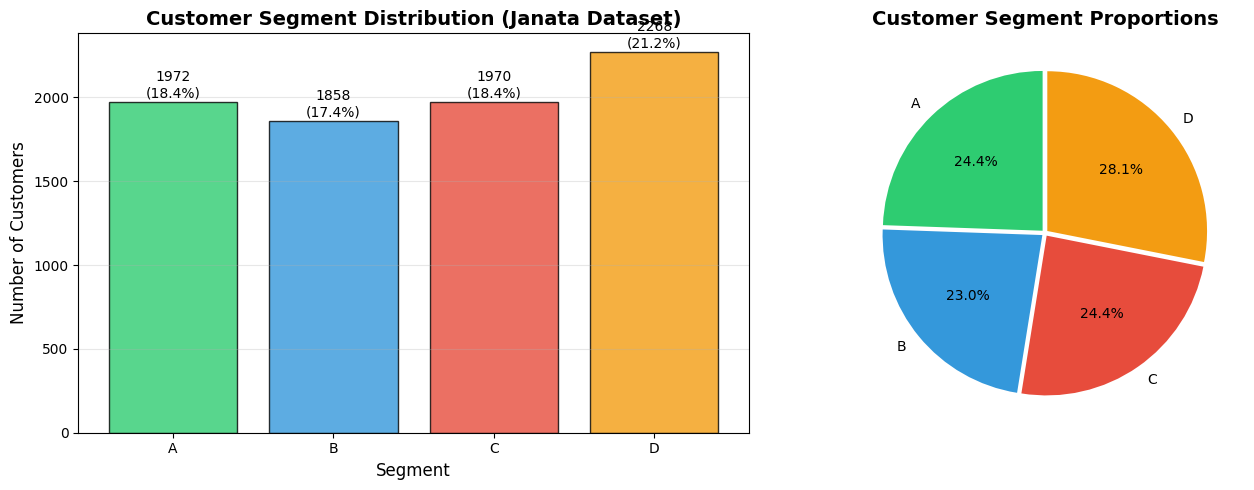


Class distribution figure saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures\class_distribution.png


In [44]:
# Figure 1: Class Distribution Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Customer Segment Distribution (Janata Dataset)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segment', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count, pct in zip(bars, class_counts.values, class_percentages.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90, explode=[0.02, 0.02, 0.02, 0.02])
axes[1].set_title('Customer Segment Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nClass distribution figure saved to: {FIGURES_DIR / 'class_distribution.png'}")


### 2.5 Feature Type Taxonomy


In [45]:
# Define feature groups based on domain knowledge
feature_groups = {
    'demographic': ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size'],
    'psychographic': ['Spending_Score', 'Var_1'],
    'behavioral': ['Work_Experience'],
}

# Identify which features are actually present
DEMOGRAPHIC = [col for col in feature_groups['demographic'] if col in df.columns]
PSYCHOGRAPHIC = [col for col in feature_groups['psychographic'] if col in df.columns]
BEHAVIORAL = [col for col in feature_groups['behavioral'] if col in df.columns]

# Identify numeric, categorical, and binary columns
numeric_cols = []
categorical_cols = []
binary_cols = []
ordinal_cols = []

for col in ALL_FEATURES:
    if pd.api.types.is_numeric_dtype(df[col]):
        # Check if it's actually binary (only 0/1 values)
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1}):
            binary_cols.append(col)
        else:
            numeric_cols.append(col)
    else:
        # Check if it's binary (only two categories)
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) == 2:
            binary_cols.append(col)
        else:
            categorical_cols.append(col)

print("\nFeature Taxonomy Summary:")
print(f"  - Demographic features: {DEMOGRAPHIC}")
print(f"  - Psychographic features: {PSYCHOGRAPHIC}")
print(f"  - Behavioral features: {BEHAVIORAL}")
print(f"\n  - Numeric features: {numeric_cols}")
print(f"  - Categorical features: {categorical_cols}")
print(f"  - Binary features: {binary_cols}")



Feature Taxonomy Summary:
  - Demographic features: ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size']
  - Psychographic features: ['Spending_Score', 'Var_1']
  - Behavioral features: ['Work_Experience']

  - Numeric features: ['Age', 'Work_Experience', 'Family_Size']
  - Categorical features: ['Profession', 'Spending_Score', 'Var_1']
  - Binary features: ['Gender', 'Ever_Married', 'Graduated']


### 2.6 Numerical Feature Distributions


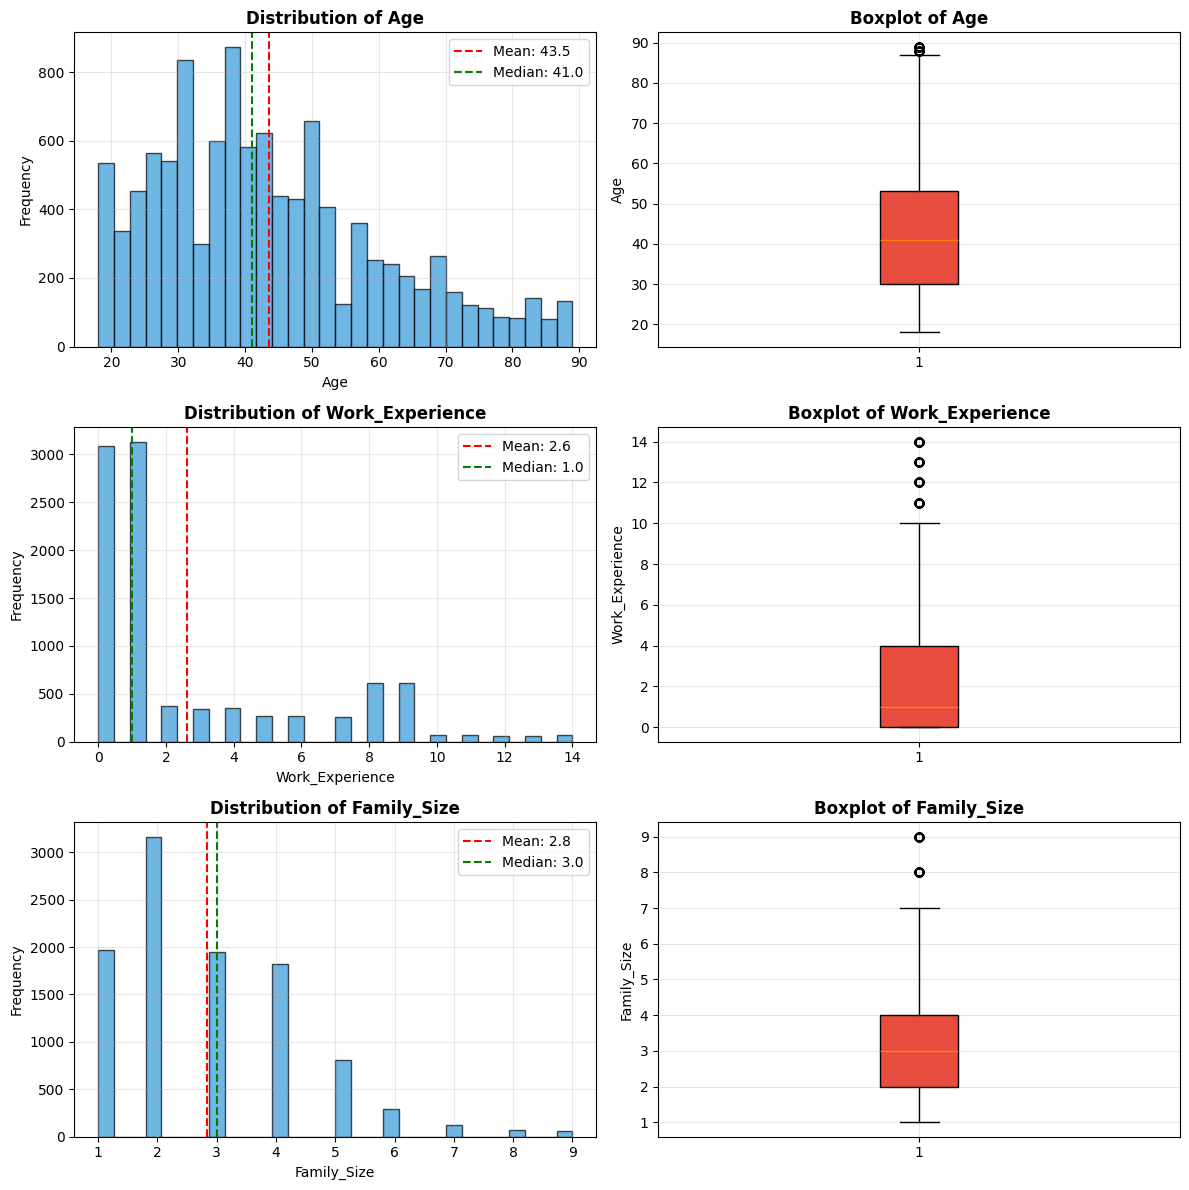

In [46]:
# Figure 2: Numerical Feature Distributions (Histograms + Boxplots)
if numeric_cols:
    n_cols = len(numeric_cols)
    fig, axes = plt.subplots(n_cols, 2, figsize=(12, 4*n_cols))
    
    if n_cols == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(numeric_cols):
        # Histogram
        axes[i, 0].hist(df[col].dropna(), bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
        axes[i, 0].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
        axes[i, 0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i, 0].set_xlabel(col, fontsize=10)
        axes[i, 0].set_ylabel('Frequency', fontsize=10)
        axes[i, 0].legend()
        axes[i, 0].grid(alpha=0.3)
        
        # Boxplot
        box = axes[i, 1].boxplot(df[col].dropna(), vert=True, patch_artist=True)
        box['boxes'][0].set_facecolor('#e74c3c')
        axes[i, 1].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel(col, fontsize=10)
        axes[i, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'numerical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()


### 2.7 Categorical Feature Frequency Plots

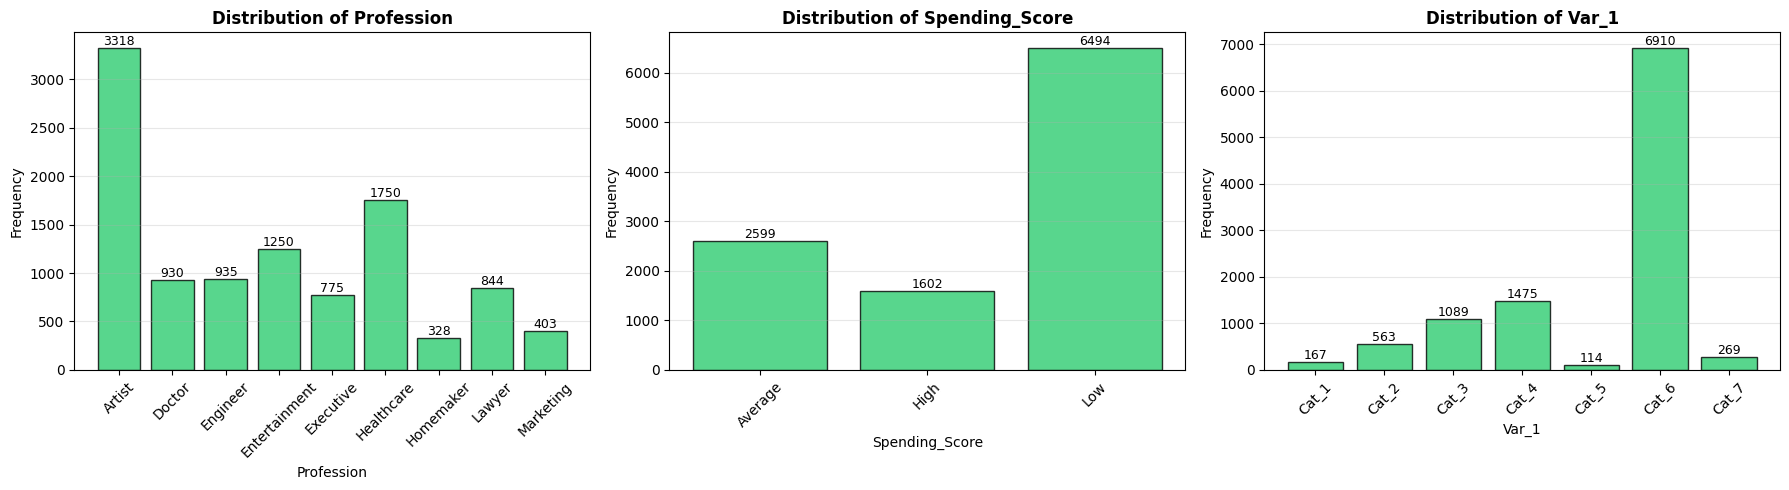

In [47]:
# Figure 3: Categorical Frequency Plots
if categorical_cols:
    n_cols = len(categorical_cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 5))
    
    if n_cols == 1:
        axes = [axes]
    
    for i, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts().sort_index()
        axes[i].bar(value_counts.index, value_counts.values, color='#2ecc71', edgecolor='black', alpha=0.8)
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bar, count in zip(axes[i].patches, value_counts.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                        str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'categorical_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

### 2.8 Spending vs. Experience Scatter Plot


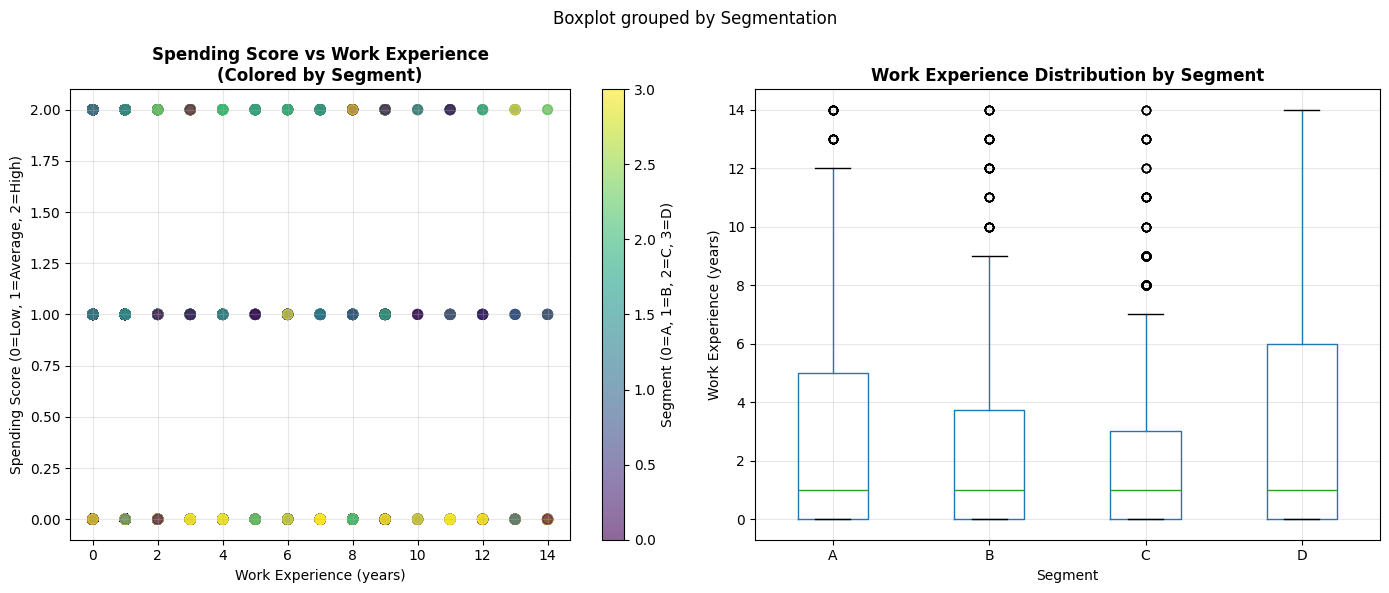


Figure saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures\spending_experience_scatter.png


In [48]:
# Figure 4: Spending Score vs Work Experience (mapped to RFM-like plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: Work Experience vs Spending Score
# Map Spending_Score to numeric for plotting
spending_map = {'Low': 0, 'Average': 1, 'High': 2}
df['Spending_Score_Numeric'] = df['Spending_Score'].map(spending_map)

scatter = axes[0].scatter(df['Work_Experience'], df['Spending_Score_Numeric'],
                         c=df['Segmentation'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3}),
                         cmap='viridis', alpha=0.6, s=50)
axes[0].set_title('Spending Score vs Work Experience\n(Colored by Segment)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Work Experience (years)', fontsize=10)
axes[0].set_ylabel('Spending Score (0=Low, 1=Average, 2=High)', fontsize=10)
axes[0].grid(alpha=0.3)

# Add colorbar legend
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Segment (0=A, 1=B, 2=C, 3=D)', fontsize=10)

# Boxplot: Work Experience by Segment
df_clean = df.dropna(subset=['Work_Experience', 'Segmentation'])
df_clean.boxplot(column='Work_Experience', by='Segmentation', ax=axes[1])
axes[1].set_title('Work Experience Distribution by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Segment', fontsize=10)
axes[1].set_ylabel('Work Experience (years)', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'spending_experience_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {FIGURES_DIR / 'spending_experience_scatter.png'}")

### 2.9 Numeric Feature-by-Target Boxplots


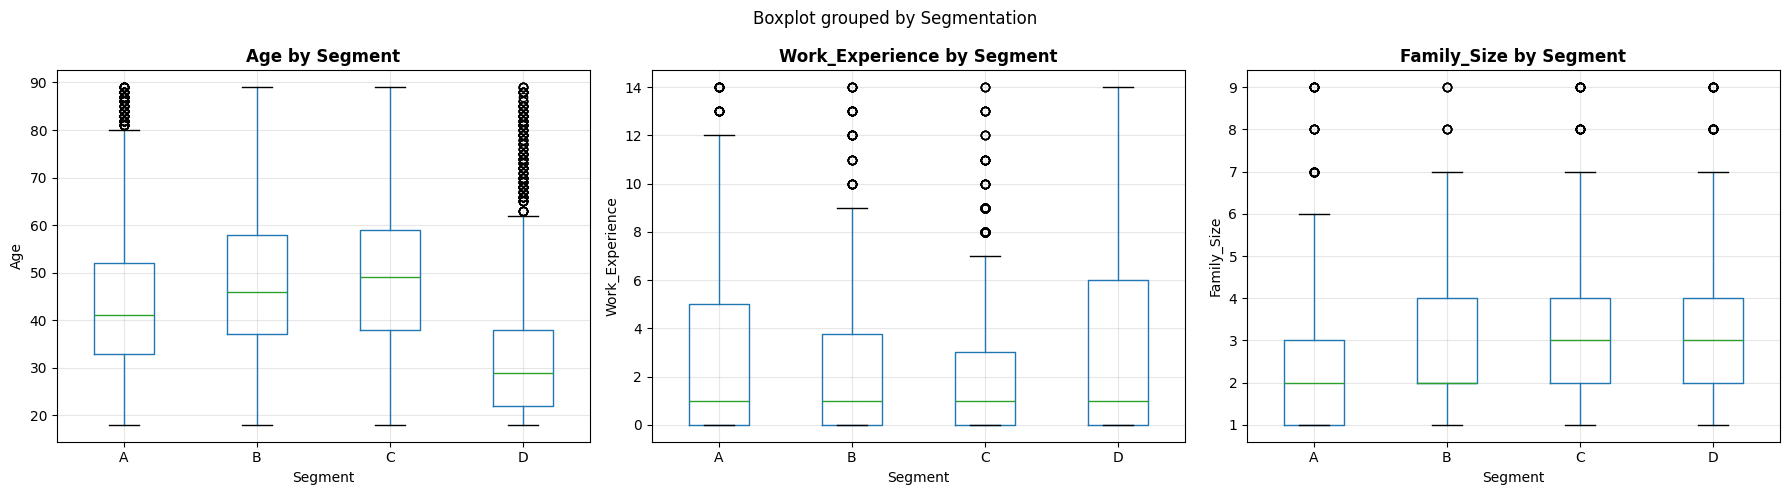

In [49]:
# Figure 5: Numeric Features Boxplots by Segment
if numeric_cols:
    n_cols = len(numeric_cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 5))
    
    if n_cols == 1:
        axes = [axes]
    
    for i, col in enumerate(numeric_cols):
        df_clean = df.dropna(subset=[col, 'Segmentation'])
        df_clean.boxplot(column=col, by='Segmentation', ax=axes[i])
        axes[i].set_title(f'{col} by Segment', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Segment', fontsize=10)
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'numeric_by_target_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()

### 2.10 Missingness Pattern Heatmap

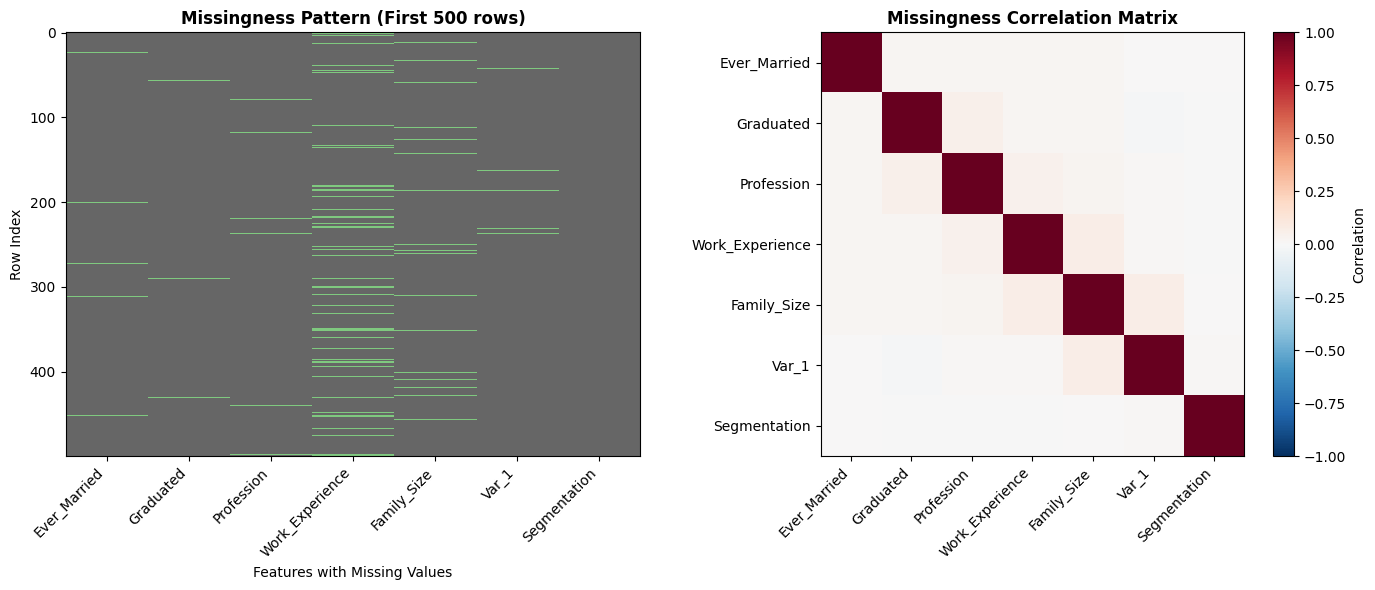

In [50]:
# Figure 6: Missingness Pattern Heatmap
if missing_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Missingness matrix (sample of rows)
    missing_sample = df[missing_cols].isna().iloc[:500]
    axes[0].imshow(missing_sample, aspect='auto', cmap='Accent_r', interpolation='nearest')
    axes[0].set_title('Missingness Pattern (First 500 rows)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Features with Missing Values', fontsize=10)
    axes[0].set_ylabel('Row Index', fontsize=10)
    axes[0].set_xticks(range(len(missing_cols)))
    axes[0].set_xticklabels(missing_cols, rotation=45, ha='right')
    
    # Missingness correlation heatmap
    if len(missing_cols) > 1:
        missing_corr = df[missing_cols].isna().corr()
        im = axes[1].imshow(missing_corr, cmap='RdBu_r', vmin=-1, vmax=1)
        axes[1].set_title('Missingness Correlation Matrix', fontsize=12, fontweight='bold')
        axes[1].set_xticks(range(len(missing_cols)))
        axes[1].set_yticks(range(len(missing_cols)))
        axes[1].set_xticklabels(missing_cols, rotation=45, ha='right')
        axes[1].set_yticklabels(missing_cols)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=axes[1])
        cbar.set_label('Correlation', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'missingness_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()

### 2.11 Age vs Work Experience Scatter (Suspicious Zero Analysis)


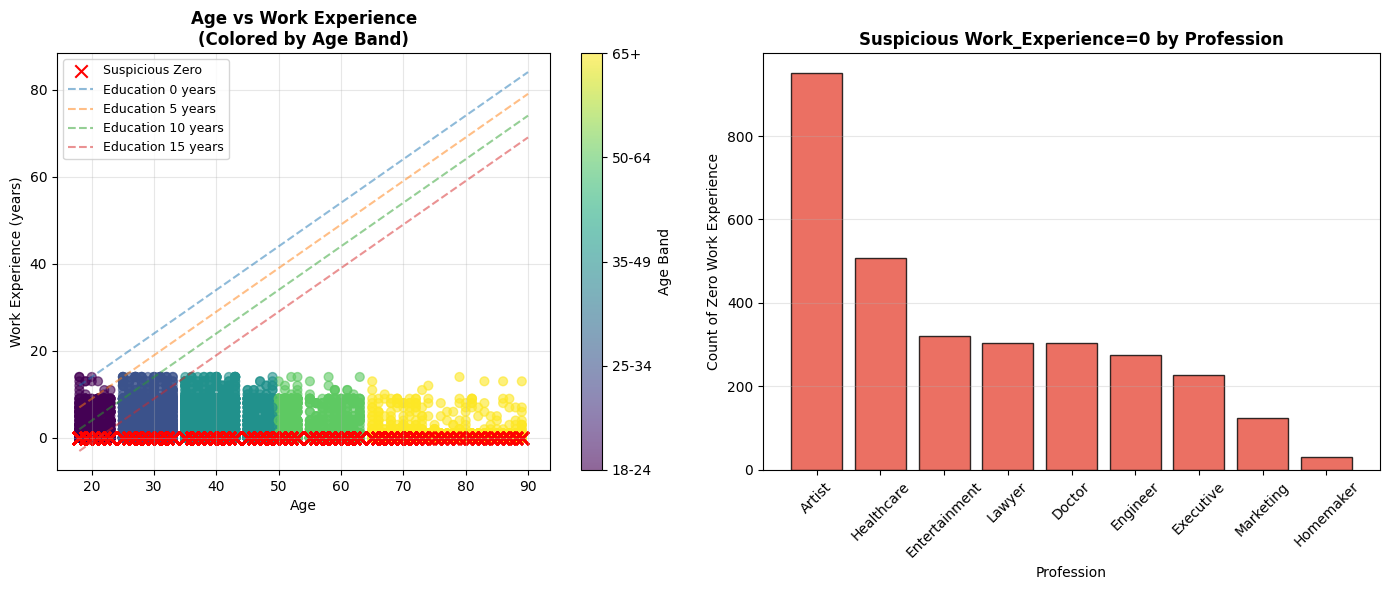


Suspicious Zero Analysis:
  - Total records with Work_Experience = 0: 3087
  - Percentage of records: 28.9%

Suspicious zeros by Profession:
Profession
Artist           951
Healthcare       508
Entertainment    321
Lawyer           303
Doctor           303
Engineer         276
Executive        227
Marketing        125
Homemaker         31


In [51]:
# Figure 7: Age vs Work Experience colored by Age Band
def get_age_band(age):
    if age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 50:
        return '35-49'
    elif age < 65:
        return '50-64'
    else:
        return '65+'

df['Age_Band'] = df['Age'].apply(get_age_band)

# Create age band order
age_band_order = ['18-24', '25-34', '35-49', '50-64', '65+']
df['Age_Band_Ordered'] = pd.Categorical(df['Age_Band'], categories=age_band_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: Age vs Work Experience
scatter = axes[0].scatter(df['Age'], df['Work_Experience'],
                         c=df['Age_Band_Ordered'].cat.codes,
                         cmap='viridis', alpha=0.6, s=40)
axes[0].set_title('Age vs Work Experience\n(Colored by Age Band)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=10)
axes[0].set_ylabel('Work Experience (years)', fontsize=10)
axes[0].grid(alpha=0.3)

# Add colorbar legend
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Age Band', fontsize=10)
cbar.set_ticks(range(5))
cbar.set_ticklabels(age_band_order)

# Highlight suspicious zeros
suspicious = df[df['Work_Experience'] == 0]
axes[0].scatter(suspicious['Age'], suspicious['Work_Experience'],
               color='red', s=80, marker='x', label='Suspicious Zero')

# Add theoretical line: Work_Experience ≈ Age - Education_Years - 6
# Assuming typical education: 0-12 years (for educated vs non-educated)
ages = np.linspace(18, 90, 100)
for edu_years in [0, 5, 10, 15]:
    axes[0].plot(ages, ages - edu_years - 6, '--', alpha=0.5,
                label=f'Education {edu_years} years')

axes[0].legend(loc='upper left', fontsize=9)

# Bar chart: Suspicious Zero counts by Profession
suspicious_by_prof = suspicious['Profession'].value_counts()
axes[1].bar(suspicious_by_prof.index, suspicious_by_prof.values,
           color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title('Suspicious Work_Experience=0 by Profession', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Profession', fontsize=10)
axes[1].set_ylabel('Count of Zero Work Experience', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'age_experience_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSuspicious Zero Analysis:")
print(f"  - Total records with Work_Experience = 0: {len(suspicious)}")
print(f"  - Percentage of records: {100 * len(suspicious) / len(df):.1f}%")
print(f"\nSuspicious zeros by Profession:")
print(suspicious_by_prof.to_string())


### 2.12 Correlation Heatmap


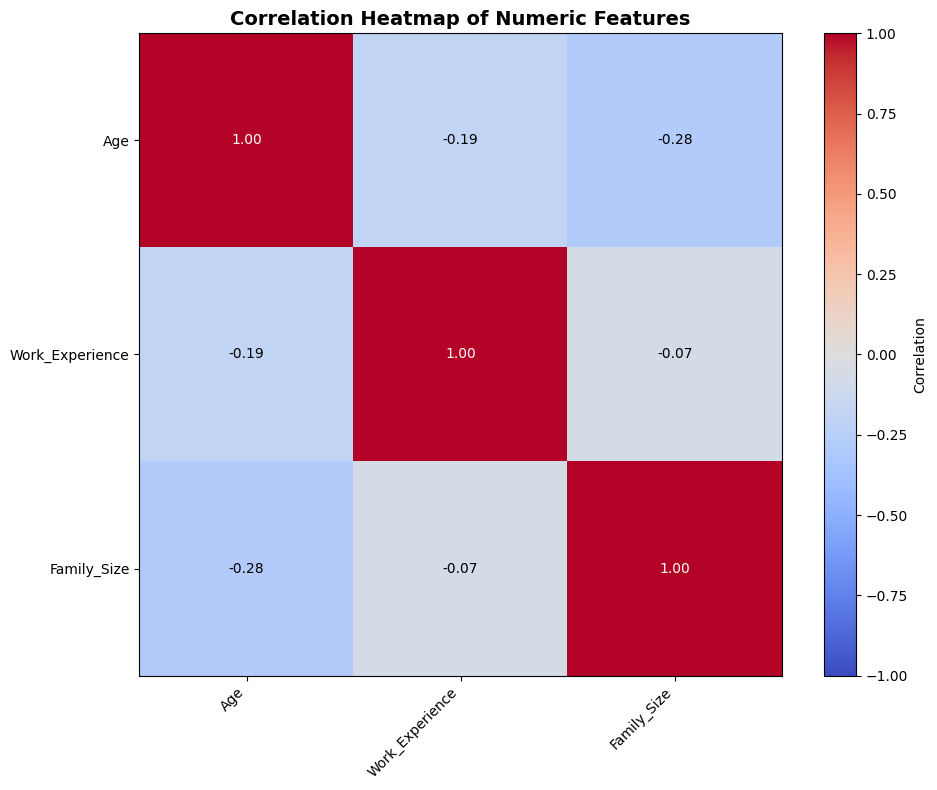

In [52]:
# Figure 8: Correlation Heatmap of Numeric Features
if len(numeric_cols) > 1:
    # Select numeric columns
    numeric_df = df[numeric_cols].copy()
    
    # Encode categorical columns for correlation
    for col in numeric_cols:
        if df[col].dtype == 'object':
            numeric_df[col] = df[col].astype('category').cat.codes
    
    # Compute correlation matrix
    corr_matrix = numeric_df.corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    
    # Add labels
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
    
    # Add correlation values
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center",
                          color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black",
                          fontsize=10)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlation', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


# 3. PREPROCESSING AND DATA PREPARATION

> This section handles all preprocessing steps :
> - Handling suspicious zeros in Work_Experience
> - Creating a leakage-safe train/test split
> - Building model-specific preprocessing pipelines

### 3.1 Handle Suspicious Zeros in Work_Experience


In [53]:
"""
WORK_EXPERIENCE ZERO ANALYSIS

I observed that many records have Work_Experience = 0, which seems implausible
for older individuals. This is likely missing data encoded as 0.

My strategy:
1. For records with Age <= 22 and Work_Experience = 0: Keep as 0 (plausible)
2. For records with Age > 22 and Work_Experience = 0: Treat as missing
3. Impute missing Work_Experience using median by Age band and Profession
"""

# Create a copy for preprocessing
df_clean = df.copy()

# Flag suspicious zeros (Age > 22 and Work_Experience = 0)
df_clean['Work_Experience_Suspicious'] = (df_clean['Work_Experience'] == 0) & (df_clean['Age'] > 22)

print(f"Suspicious Work_Experience zeros: {df_clean['Work_Experience_Suspicious'].sum()} records")

# For modeling, I will treat Work_Experience=0 for Age>22 as missing
# Create a cleaned Work_Experience column
df_clean['Work_Experience_Cleaned'] = df_clean['Work_Experience'].copy()
df_clean.loc[df_clean['Work_Experience_Suspicious'], 'Work_Experience_Cleaned'] = np.nan

print(f"Work_Experience missing values after cleaning: {df_clean['Work_Experience_Cleaned'].isna().sum()}")

Suspicious Work_Experience zeros: 2813 records
Work_Experience missing values after cleaning: 3911


### 3.2 Define Feature Groups and Preprocessing Strategy


In [54]:
# Based on EDA, define final feature lists
NUMERIC_COLS = ['Age', 'Work_Experience_Cleaned']
CATEGORICAL_COLS = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
BINARY_COLS = []  # No pure binary columns identified in EDA
ORDINAL_COLS = ['Family_Size']  # Ordinal numeric

# For BernoulliNB: need to discretize numeric features into binary indicators
# For CategoricalNB: need to ordinal encode categorical features

print(f"\nFinal Feature Groups:")
print(f"  - Numeric features (for GaussianNB): {NUMERIC_COLS}")
print(f"  - Categorical features (for CategoricalNB): {CATEGORICAL_COLS}")
print(f"  - Ordinal features (for all models): {ORDINAL_COLS}")


Final Feature Groups:
  - Numeric features (for GaussianNB): ['Age', 'Work_Experience_Cleaned']
  - Categorical features (for CategoricalNB): ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
  - Ordinal features (for all models): ['Family_Size']


### 3.3 Create Locked Train/Test Split


In [55]:
# Use the cleaned experience column in the model features
MODEL_FEATURES = [
    col for col in ALL_FEATURES
    if col != 'Work_Experience'
]

MODEL_FEATURES.append('Work_Experience_Cleaned')
# Separate target and features
X = df_clean[MODEL_FEATURES].copy()
y = df_clean[TARGET_COL].copy()

# Verify target is present
if y.isna().any():
    print(f"⚠️ WARNING: {y.isna().sum()} records have missing target. Dropping them.")
    mask = ~y.isna()
    X = X[mask]
    y = y[mask]

print(f"Dataset size after dropping missing target: {len(X)} records")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Create stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=SEED, 
    stratify=y
)

print(f"\nTrain set size: {len(X_train)} ({(100 * len(X_train) / len(X)):.1f}%)")
print(f"Test set size: {len(X_test)} ({(100 * len(X_test) / len(X)):.1f}%)")

# Save split manifest
split_manifest = pd.DataFrame({
    'ID': df_clean.loc[X_train.index, ID_COL].tolist() + df_clean.loc[X_test.index, ID_COL].tolist(),
    'split': ['train'] * len(X_train) + ['test'] * len(X_test)
})
split_manifest.to_csv(ARTIFACTS_DIR / 'split_manifest.csv', index=False)

print(f"\nSplit manifest saved to: {ARTIFACTS_DIR / 'split_manifest.csv'}")

# Verify no ID overlap
train_ids = set(df_clean.loc[X_train.index, ID_COL])
test_ids = set(df_clean.loc[X_test.index, ID_COL])
overlap = train_ids.intersection(test_ids)

print(f"\nID Overlap Check:")
print(f"  - Train IDs: {len(train_ids)}")
print(f"  - Test IDs: {len(test_ids)}")
print(f"  - Overlap: {len(overlap)}")
if overlap:
    print(f"  ⚠️ WARNING: ID overlap detected!")
else:
    print(f"  ✓ No ID overlap - split is clean!")


⚠️ WARNING: 2627 records have missing target. Dropping them.
Dataset size after dropping missing target: 8068 records
Target distribution: {'D': 2268, 'A': 1972, 'C': 1970, 'B': 1858}

Train set size: 6454 (80.0%)
Test set size: 1614 (20.0%)

Split manifest saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\artifacts\split_manifest.csv

ID Overlap Check:
  - Train IDs: 6454
  - Test IDs: 1614
  - Overlap: 0
  ✓ No ID overlap - split is clean!


### 3.4 Model-Specific Preprocessing Pipelines


In [56]:
# ----- 3.4.1 Base Preprocessors -----

# Numeric preprocessor (for GaussianNB)
numeric_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Numeric preprocessor for BernoulliNB (discretize to binary)
numeric_binary_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('discretizer', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile'))
])

# Categorical preprocessor (for BernoulliNB - one-hot encoding)
categorical_onehot_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ordinal preprocessor (for CategoricalNB - safe non-negative integer encoding)
class SafeOrdinalToNonNegative:
    """Encode categories to non-negative integers with reserved code for unknown."""
    def __init__(self):
        self.enc = None
        
    def fit(self, X, y=None):
        self.enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.enc.fit(X)
        return self
    
    def transform(self, X):
        # Encode, then shift to make all values non-negative (unknown becomes 0)
        encoded = self.enc.transform(X).astype(int)
        return encoded + 1  # Unknown (-1) becomes 0, known values become 1..K

# Ordinal preprocessor for CategoricalNB
categorical_ordinal_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('safe_ordinal', SafeOrdinalToNonNegative())
])

# Numeric preprocessor for CategoricalNB (discretize to ordinal)
numeric_ordinal_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('discretizer', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'))
])

# Impute Family_Size before passing it to the models
ordinal_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'))
])

# ----- 3.4.2 Build Complete Pipelines -----

# Pipeline 1: GaussianNB (numeric features only)
gaussian_preprocessor = ColumnTransformer([
    ('num', numeric_preprocessor, NUMERIC_COLS)
], remainder='drop')

# Pipeline 2: BernoulliNB (binary/dummy features)
bernoulli_preprocessor = ColumnTransformer([
    ('num_binary', numeric_binary_preprocessor, NUMERIC_COLS),
    ('cat_onehot', categorical_onehot_preprocessor, CATEGORICAL_COLS),
    ('ordinal', ordinal_preprocessor, ORDINAL_COLS)  # Family_Size is already numeric
], remainder='drop')

# Pipeline 3: CategoricalNB (ordinal encoded features)
categorical_nb_preprocessor = ColumnTransformer([
    ('num_ordinal', numeric_ordinal_preprocessor, NUMERIC_COLS),
    ('cat_ordinal', categorical_ordinal_preprocessor, CATEGORICAL_COLS),
    ('ordinal', ordinal_preprocessor, ORDINAL_COLS)  # Family_Size is already numeric
], remainder='drop')
print("✓ Preprocessing pipelines defined successfully!")

# ----- 3.4.3 Verify CategoricalNB Inputs are Non-Negative -----

# Fit and transform on training data only
X_train_cat_transformed = categorical_nb_preprocessor.fit_transform(X_train)

# Check for negative values
min_val = np.min(X_train_cat_transformed)
if min_val >= 0:
    print(f"\n✓ CategoricalNB inputs verified: all values are non-negative (min = {min_val})")
else:
    print(f"\n⚠️ WARNING: CategoricalNB inputs contain negative values (min = {min_val})")

# ----- 3.4.4 Create Full Model Pipelines -----

# Dummy baseline (using Bernoulli preprocessing for compatibility)
dummy_pipeline = Pipeline([
    ('prep', bernoulli_preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

# GaussianNB pipeline
gaussian_pipeline = Pipeline([
    ('prep', gaussian_preprocessor),
    ('model', GaussianNB(var_smoothing=1e-9))
])

# BernoulliNB pipeline
bernoulli_pipeline = Pipeline([
    ('prep', bernoulli_preprocessor),
    ('model', BernoulliNB(alpha=1.0, binarize=0.0))
])

# CategoricalNB pipeline
categorical_pipeline = Pipeline([
    ('prep', categorical_nb_preprocessor),
    ('model', CategoricalNB(alpha=1.0))
])

# Store all pipelines in a dictionary
core_pipelines = {
    'DummyClassifier': dummy_pipeline,
    'GaussianNB': gaussian_pipeline,
    'BernoulliNB': bernoulli_pipeline,
    'CategoricalNB': categorical_pipeline
}

# Verify each pipeline can fit and predict
print("\nVerifying pipelines can fit and predict...")
for name, pipe in core_pipelines.items():
    try:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_train[:5])
        print(f"  ✓ {name}: fit and predict successful")
    except Exception as e:
        print(f"  ✗ {name}: Error - {str(e)}")

✓ Preprocessing pipelines defined successfully!

✓ CategoricalNB inputs verified: all values are non-negative (min = 0.0)

Verifying pipelines can fit and predict...


  ✓ DummyClassifier: fit and predict successful
  ✓ GaussianNB: fit and predict successful
  ✓ BernoulliNB: fit and predict successful
  ✓ CategoricalNB: fit and predict successful


### 3.5 Feature Group Ablation Setup


In [57]:
# Define feature groups for ablation experiments
feature_groups = {
    'demographic_only': ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size'],
    'psychographic_only': ['Spending_Score', 'Var_1'],
    'behavioral_only': ['Work_Experience_Cleaned'],
    'combined': ALL_FEATURES  # Using all features
}

print("Feature Groups for Ablation:")
for group_name, features in feature_groups.items():
    print(f"  - {group_name}: {len(features)} features")
    print(f"    {features}")

Feature Groups for Ablation:
  - demographic_only: 6 features
    ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size']
  - psychographic_only: 2 features
    ['Spending_Score', 'Var_1']
  - behavioral_only: 1 features
    ['Work_Experience_Cleaned']
  - combined: 9 features
    ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']


### 3.6 Save Preprocessed Data and Artifacts


In [58]:
# Save preprocessed training and test sets
preprocessed_dir = DATA_PROCESSED / 'janata'
preprocessed_dir.mkdir(parents=True, exist_ok=True)

# Save the processed data
X_train.to_csv(preprocessed_dir / 'X_train.csv', index=False)
X_test.to_csv(preprocessed_dir / 'X_test.csv', index=False)
y_train.to_csv(preprocessed_dir / 'y_train.csv', index=False)
y_test.to_csv(preprocessed_dir / 'y_test.csv', index=False)

# Save feature metadata
feature_metadata = {
    'all_features': ALL_FEATURES,
    'numeric_features': NUMERIC_COLS,
    'categorical_features': CATEGORICAL_COLS,
    'ordinal_features': ORDINAL_COLS,
    'target_column': TARGET_COL,
    'id_column': ID_COL,
    'feature_groups': feature_groups
}

with open(ARTIFACTS_DIR / 'feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)

print(f"✓ Preprocessed data saved to: {preprocessed_dir}")
print(f"✓ Feature metadata saved to: {ARTIFACTS_DIR / 'feature_metadata.json'}")

print("\n" + "="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print("Summary:")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - Features: {len(ALL_FEATURES)}")
print(f"  - Classes: {len(y_train.unique())}")
print(f"  - Class balance: {dict(y_train.value_counts(normalize=True).round(3))}")

✓ Preprocessed data saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\data\processed\janata
✓ Feature metadata saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\artifacts\feature_metadata.json

PREPROCESSING COMPLETE
Summary:
  - Training samples: 6454
  - Test samples: 1614
  - Features: 9
  - Classes: 4
  - Class balance: {'D': np.float64(0.281), 'A': np.float64(0.244), 'C': np.float64(0.244), 'B': np.float64(0.23)}


# 4. CROSS-VALIDATION AND MODEL TRAINING
> This section implements the core model training workflow:
> - 5-fold StratifiedKFold cross-validation
> - Training and evaluation of all four core models
> - Model selection based on training-only evidence
> - Feature-group ablation experiments


### 4.1 Create Safe Ordinal Encoder for CategoricalNB


In [59]:
class SafeOrdinalToNonNegative(BaseEstimator, TransformerMixin):
    """
    Encode categories to non-negative integers with reserved code for unknown values.
    
    This transformer ensures that:
    1. All category values are mapped to non-negative integers
    2. Unknown categories encountered during transform are mapped to 0
    3. Known categories are mapped to 1, 2, 3, ..., K
    
    This is required for CategoricalNB which only accepts non-negative integer inputs.
    """
    def __init__(self):
        self.enc = None
        
    def fit(self, X, y=None):
        # Fit OrdinalEncoder with unknown handling
        self.enc = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )
        self.enc.fit(X)
        return self
    
    def transform(self, X):
        # Encode, then shift to make all values non-negative
        # Unknown categories (-1) become 0, known categories become 1..K
        encoded = self.enc.transform(X).astype(int)
        return encoded + 1

### 4.2 Define Feature Lists and Preprocessors

In [60]:
# Feature lists from preprocessing
NUMERIC_COLS = ['Age', 'Work_Experience_Cleaned']
CATEGORICAL_COLS = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
ORDINAL_COLS = ['Family_Size']

# Numeric preprocessor for GaussianNB
numeric_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Numeric preprocessor for BernoulliNB (discretize to binary)
numeric_binary_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('discretizer', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile'))
])

# Categorical preprocessor for BernoulliNB (one-hot encoding)
categorical_onehot_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Numeric preprocessor for CategoricalNB (discretize to ordinal)
numeric_ordinal_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('discretizer', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'))
])

# Categorical preprocessor for CategoricalNB (safe ordinal encoding)
categorical_ordinal_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('safe_ordinal', SafeOrdinalToNonNegative())
])

# Preprocessor for Family_Size
ordinal_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', KBinsDiscretizer(
        n_bins=5,
        encode='ordinal',
        strategy='quantile'
    ))
])

### 4.3 Build Model-Specific Pipelines

In [61]:
# Pipeline 1: GaussianNB (numeric features only)
gaussian_preprocessor = ColumnTransformer([
    ('num', numeric_preprocessor, NUMERIC_COLS)
], remainder='drop')

gaussian_pipeline = Pipeline([
    ('prep', gaussian_preprocessor),
    ('model', GaussianNB(var_smoothing=1e-9))
])

# Pipeline 2: BernoulliNB (binary/dummy features)
bernoulli_preprocessor = ColumnTransformer([
    ('num_binary', numeric_binary_preprocessor, NUMERIC_COLS),
    ('cat_onehot', categorical_onehot_preprocessor, CATEGORICAL_COLS),
    ('ordinal', ordinal_preprocessor, ORDINAL_COLS)
], remainder='drop')

bernoulli_pipeline = Pipeline([
    ('prep', bernoulli_preprocessor),
    ('model', BernoulliNB(alpha=1.0, binarize=0.0))
])

# Pipeline 3: CategoricalNB (ordinal encoded features)
categorical_nb_preprocessor = ColumnTransformer([
    ('num_ordinal', numeric_ordinal_preprocessor, NUMERIC_COLS),
    ('cat_ordinal', categorical_ordinal_preprocessor, CATEGORICAL_COLS),
    ('ordinal', ordinal_preprocessor, ORDINAL_COLS)
], remainder='drop')

categorical_pipeline = Pipeline([
    ('prep', categorical_nb_preprocessor),
    ('model', CategoricalNB(alpha=1.0))
])

# Pipeline 4: DummyClassifier (baseline)
dummy_preprocessor = bernoulli_preprocessor  # Reuse Bernoulli preprocessor

dummy_pipeline = Pipeline([
    ('prep', dummy_preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

# Store all pipelines in a dictionary
core_pipelines = {
    'DummyClassifier': dummy_pipeline,
    'GaussianNB': gaussian_pipeline,
    'BernoulliNB': bernoulli_pipeline,
    'CategoricalNB': categorical_pipeline
}

print("✓ Core pipelines defined successfully!")
for name in core_pipelines:
    print(f"  - {name}")

✓ Core pipelines defined successfully!
  - DummyClassifier
  - GaussianNB
  - BernoulliNB
  - CategoricalNB


### 4.4 Universal Cross-Validation Function

In [62]:
def cross_validate_model(pipeline, X, y, n_splits=5, random_state=42):
    """
    Perform cross-validation on a given pipeline and return comprehensive results.
    
    Parameters:
    -----------
    pipeline : sklearn Pipeline
        The model pipeline to evaluate
    X : DataFrame
        Feature matrix
    y : Series
        Target labels
    n_splits : int
        Number of cross-validation folds
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    dict : Dictionary containing CV results with mean and standard deviation
    """
    # Define scoring metrics
    scoring = {
        'accuracy': 'accuracy',
        'macro_f1': 'f1_macro',
        'weighted_f1': 'f1_weighted'
    }
    
    # Create stratified K-Fold
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    # Perform cross-validation
    start_time = time.perf_counter()
    scores = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    elapsed_time = time.perf_counter() - start_time
    
    # Extract results
    results = {
        'accuracy_mean': np.mean(scores['test_accuracy']),
        'accuracy_std': np.std(scores['test_accuracy'], ddof=1),
        'macro_f1_mean': np.mean(scores['test_macro_f1']),
        'macro_f1_std': np.std(scores['test_macro_f1'], ddof=1),
        'weighted_f1_mean': np.mean(scores['test_weighted_f1']),
        'weighted_f1_std': np.std(scores['test_weighted_f1'], ddof=1),
        'fold_scores': scores['test_macro_f1'].tolist(),
        'cv_time': elapsed_time
    }
    
    return results

### 4.5 Train and Cross-Validate All Core Models


In [63]:
cv_results = {}
cv_fold_scores = {}

for name, pipeline in core_pipelines.items():
    print(f"\nEvaluating {name}...")
    
    try:
        # Perform cross-validation
        results = cross_validate_model(pipeline, X_train, y_train)
        cv_results[name] = results
        cv_fold_scores[name] = results['fold_scores']
        
        print(f"  ✓ Macro F1: {results['macro_f1_mean']:.4f} ± {results['macro_f1_std']:.4f}")
        print(f"  ✓ Weighted F1: {results['weighted_f1_mean']:.4f} ± {results['weighted_f1_std']:.4f}")
        print(f"  ✓ Accuracy: {results['accuracy_mean']:.4f} ± {results['accuracy_std']:.4f}")
        print(f"  ✓ CV Time: {results['cv_time']:.2f} seconds")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        cv_results[name] = None
        cv_fold_scores[name] = None

# Convert results to DataFrame for easy viewing
cv_df = pd.DataFrame([
    {
        'Model': name,
        'Macro_F1_Mean': results['macro_f1_mean'] if results else np.nan,
        'Macro_F1_Std': results['macro_f1_std'] if results else np.nan,
        'Weighted_F1_Mean': results['weighted_f1_mean'] if results else np.nan,
        'Accuracy_Mean': results['accuracy_mean'] if results else np.nan,
        'CV_Time_Seconds': results['cv_time'] if results else np.nan
    }
    for name, results in cv_results.items()
]).sort_values('Macro_F1_Mean', ascending=False)

# Save CV results
cv_df.to_csv(RESULTS_DIR / 'cv_results.csv', index=False)

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*60)
print(cv_df.to_string(index=False))


Evaluating DummyClassifier...


  ✓ Macro F1: 0.1097 ± 0.0001
  ✓ Weighted F1: 0.1233 ± 0.0002
  ✓ Accuracy: 0.2811 ± 0.0002
  ✓ CV Time: 14.85 seconds

Evaluating GaussianNB...
  ✓ Macro F1: 0.2744 ± 0.0121
  ✓ Weighted F1: 0.2892 ± 0.0123
  ✓ Accuracy: 0.3888 ± 0.0127
  ✓ CV Time: 9.31 seconds

Evaluating BernoulliNB...
  ✓ Macro F1: 0.4824 ± 0.0121
  ✓ Weighted F1: 0.4910 ± 0.0114
  ✓ Accuracy: 0.5034 ± 0.0115
  ✓ CV Time: 0.46 seconds

Evaluating CategoricalNB...
  ✓ Macro F1: 0.4836 ± 0.0078
  ✓ Weighted F1: 0.4929 ± 0.0073
  ✓ Accuracy: 0.5081 ± 0.0067
  ✓ CV Time: 0.33 seconds

CROSS-VALIDATION RESULTS SUMMARY
          Model  Macro_F1_Mean  Macro_F1_Std  Weighted_F1_Mean  Accuracy_Mean  CV_Time_Seconds
  CategoricalNB       0.483649      0.007802          0.492874       0.508056         0.332764
    BernoulliNB       0.482357      0.012060          0.491039       0.503409         0.455187
     GaussianNB       0.274405      0.012130          0.289236       0.388752         9.306891
DummyClassifier       0.109

### 4.7 Model Selection


In [64]:
# Select best model based on mean macro F1
best_model_name = cv_df.loc[cv_df['Macro_F1_Mean'].idxmax(), 'Model']
best_results = cv_results[best_model_name]

print(f"Selected Model: {best_model_name}")
print(f"  - Macro F1: {best_results['macro_f1_mean']:.4f} ± {best_results['macro_f1_std']:.4f}")
print(f"  - Weighted F1: {best_results['weighted_f1_mean']:.4f} ± {best_results['weighted_f1_std']:.4f}")

# Check if difference from second-best is meaningful
if len(cv_df) > 1:
    second_best = cv_df.iloc[1]
    diff = cv_df.iloc[0]['Macro_F1_Mean'] - cv_df.iloc[1]['Macro_F1_Mean']
    best_std = cv_results[cv_df.iloc[0]['Model']]['macro_f1_std']
    
    print(f"\nModel Comparison:")
    print(f"  - Best vs Second-best difference: {diff:.4f}")
    print(f"  - Best model fold std: {best_std:.4f}")
    
    if diff < best_std:
        print("  ⚠️ The difference is smaller than fold-to-fold variability.")
        print("     Do not claim superiority based on this small difference.")
    else:
        print("  ✓ The difference is larger than fold-to-fold variability.")
        print("     This suggests a meaningful performance improvement.")

# Save selection decision
selection_decision = {
    'selected_model': best_model_name,
    'selection_criteria': 'mean_macro_f1',
    'macro_f1_mean': best_results['macro_f1_mean'],
    'macro_f1_std': best_results['macro_f1_std'],
    'selection_rationale': f"Selected based on highest mean macro F1 with consideration of fold-to-fold variability.",
    'timestamp': datetime.now().isoformat()
}

with open(ARTIFACTS_DIR / 'model_selection.json', 'w') as f:
    json.dump(selection_decision, f, indent=2)

print(f"\nSelection decision saved to: {ARTIFACTS_DIR / 'model_selection.json'}")

Selected Model: CategoricalNB
  - Macro F1: 0.4836 ± 0.0078
  - Weighted F1: 0.4929 ± 0.0073

Model Comparison:
  - Best vs Second-best difference: 0.0013
  - Best model fold std: 0.0078
  ⚠️ The difference is smaller than fold-to-fold variability.
     Do not claim superiority based on this small difference.

Selection decision saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\artifacts\model_selection.json


### 4.8 Cross-Validation Comparison Plot


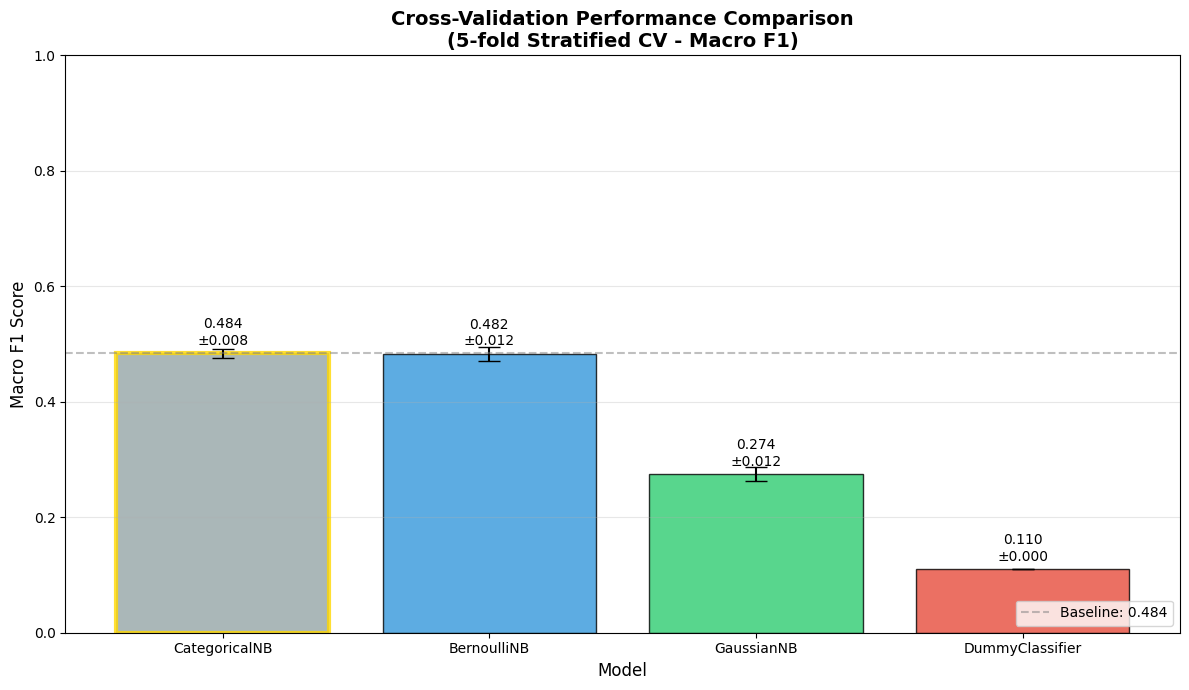


Figure saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures\cv_comparison.png


In [65]:
# Figure 9: Cross-validation comparison with error bars
fig, ax = plt.subplots(figsize=(12, 7))

models = cv_df['Model'].tolist()
means = cv_df['Macro_F1_Mean'].tolist()
stds = cv_df['Macro_F1_Std'].tolist()

colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(models, means, yerr=stds, capsize=8, 
              color=colors[:len(models)], edgecolor='black', alpha=0.8)

ax.axhline(y=means[0], color='gray', linestyle='--', alpha=0.5, label=f'Baseline: {means[0]:.3f}')

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}\n±{std:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Highlight best model
    if i == 0:
        bar.set_edgecolor('gold')
        bar.set_linewidth(3)

ax.set_title('Cross-Validation Performance Comparison\n(5-fold Stratified CV - Macro F1)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {FIGURES_DIR / 'cv_comparison.png'}")

### 4.9 Feature-Group Ablation Experiments


In [66]:
"""
FEATURE-GROUP ABLATION

I will compare the predictive performance of different feature groups using
the best-performing core model (CategoricalNB) on identical CV folds.

The feature groups are:
1. Demographic-only: Gender, Ever_Married, Age, Graduated, Profession, Family_Size
2. Psychographic-only: Spending_Score, Var_1
3. Behavioral-only: Work_Experience_Cleaned
4. Combined: All features

This helps understand:
- Which feature group provides the strongest predictive signal
- Whether integrating all groups improves performance
- Interpretability and ethical risk trade-offs
"""

def run_feature_group_ablation(feature_groups, base_pipeline, X, y, n_splits=5):
    """
    Run feature-group ablation experiments on identical CV folds.
    
    Parameters:
    -----------
    feature_groups : dict
        Dictionary mapping group names to feature lists
    base_pipeline : Pipeline
        The base model pipeline (will be adapted for each feature group)
    X : DataFrame
        Feature matrix
    y : Series
        Target labels
    n_splits : int
        Number of CV folds
    
    Returns:
    --------
    dict : Results for each feature group
    """
    results = {}
    
    # Create fixed CV folds for fair comparison
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    cv_folds = list(cv.split(X, y))
    
    for group_name, features in feature_groups.items():
        print(f"\nEvaluating {group_name}...")
        
        # Create a pipeline for this feature group
        # Reuse the CategoricalNB preprocessor with filtered columns
        X_group = X[features].copy()
        
        # Build a pipeline for this specific feature set
        # We need to handle the case where feature groups have different columns
        
        # Define group-specific preprocessors
        group_numeric = [col for col in NUMERIC_COLS if col in X_group.columns]
        group_categorical = [col for col in CATEGORICAL_COLS if col in X_group.columns]
        group_ordinal = [col for col in ORDINAL_COLS if col in X_group.columns]
        
        # Build preprocessor for this group
        group_preprocessor = ColumnTransformer([
            ('num_ordinal', numeric_ordinal_preprocessor, group_numeric),
            ('cat_ordinal', categorical_ordinal_preprocessor, group_categorical),
            ('ordinal', ordinal_preprocessor, group_ordinal)
        ], remainder='drop')
        
        group_pipeline = Pipeline([
            ('prep', group_preprocessor),
            ('model', CategoricalNB(alpha=1.0))
        ])
        
        # Perform CV with fixed folds
        fold_scores = []
        for train_idx, val_idx in cv_folds:
            X_train_fold = X_group.iloc[train_idx]
            y_train_fold = y.iloc[train_idx]
            X_val_fold = X_group.iloc[val_idx]
            y_val_fold = y.iloc[val_idx]
            
            # Fit and predict
            group_pipeline.fit(X_train_fold, y_train_fold)
            y_pred = group_pipeline.predict(X_val_fold)
            
            # Calculate macro F1
            fold_score = f1_score(y_val_fold, y_pred, average='macro')
            fold_scores.append(fold_score)
        
        results[group_name] = {
            'macro_f1_mean': np.mean(fold_scores),
            'macro_f1_std': np.std(fold_scores, ddof=1),
            'fold_scores': fold_scores
        }
        
        print(f"  ✓ Macro F1: {results[group_name]['macro_f1_mean']:.4f} ± {results[group_name]['macro_f1_std']:.4f}")
    
    return results

# Define feature groups for ablation
ablation_groups = {
    'Demographic Only': ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size'],
    'Psychographic Only': ['Spending_Score', 'Var_1'],
    'Behavioral Only': ['Work_Experience_Cleaned'],
    'Combined': ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 
                 'Work_Experience_Cleaned', 'Spending_Score', 'Family_Size', 'Var_1']
}

# Run ablation experiments
ablation_results = run_feature_group_ablation(ablation_groups, categorical_pipeline, X_train, y_train)

# Convert to DataFrame
ablation_df = pd.DataFrame([
    {
        'Feature_Group': name,
        'Macro_F1_Mean': results['macro_f1_mean'],
        'Macro_F1_Std': results['macro_f1_std'],
        'Fold_Scores': results['fold_scores']
    }
    for name, results in ablation_results.items()
]).sort_values('Macro_F1_Mean', ascending=False)

# Save ablation results
ablation_df.to_csv(RESULTS_DIR / 'ablation_results.csv', index=False)

print("\n" + "="*60)
print("FEATURE-GROUP ABLATION RESULTS")
print("="*60)
print(ablation_df[['Feature_Group', 'Macro_F1_Mean', 'Macro_F1_Std']].to_string(index=False))



Evaluating Demographic Only...
  ✓ Macro F1: 0.4790 ± 0.0103

Evaluating Psychographic Only...
  ✓ Macro F1: 0.3055 ± 0.0138

Evaluating Behavioral Only...
  ✓ Macro F1: 0.1921 ± 0.0234

Evaluating Combined...
  ✓ Macro F1: 0.4836 ± 0.0078

FEATURE-GROUP ABLATION RESULTS
     Feature_Group  Macro_F1_Mean  Macro_F1_Std
          Combined       0.483649      0.007802
  Demographic Only       0.479047      0.010251
Psychographic Only       0.305492      0.013757
   Behavioral Only       0.192067      0.023424


### 4.10 Feature-Group Comparison Plot


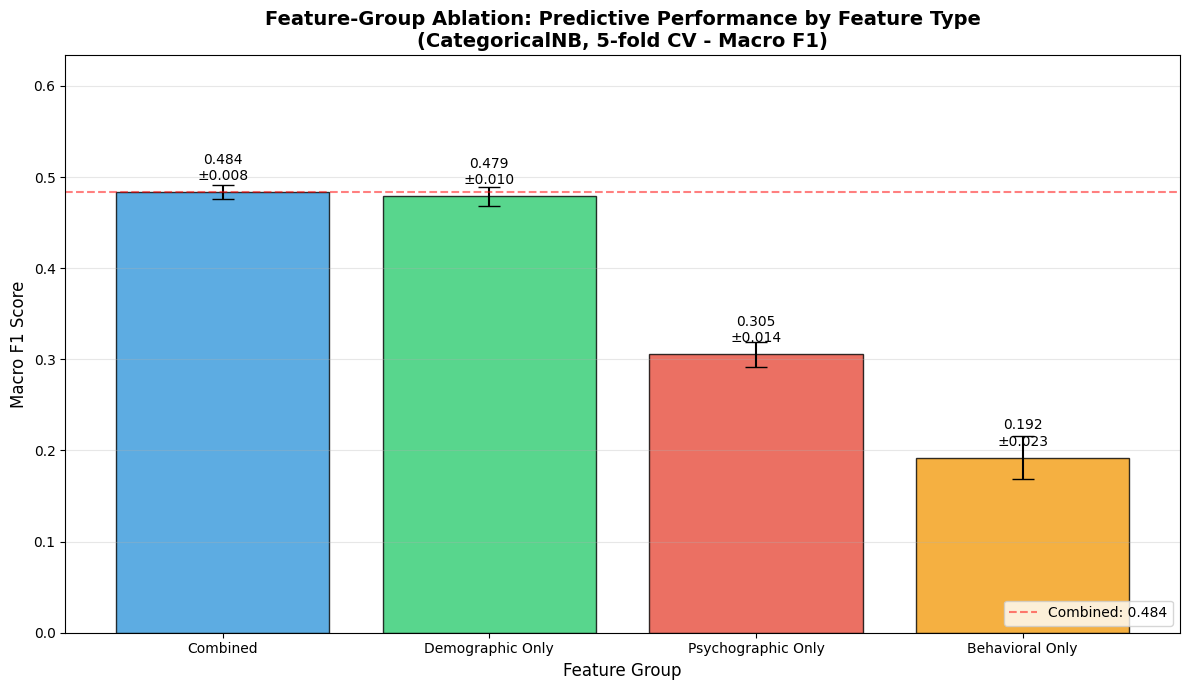


Figure saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures\feature_group_ablation.png


In [67]:
# Figure 10: Feature-group comparison bar chart
fig, ax = plt.subplots(figsize=(12, 7))

groups = ablation_df['Feature_Group'].tolist()
means = ablation_df['Macro_F1_Mean'].tolist()
stds = ablation_df['Macro_F1_Std'].tolist()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = ax.bar(groups, means, yerr=stds, capsize=8,
              color=colors[:len(groups)], edgecolor='black', alpha=0.8)

# Add value labels
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}\n±{std:.3f}', ha='center', va='bottom', fontsize=10)

# Add baseline reference
if 'Combined' in groups:
    combined_idx = groups.index('Combined')
    ax.axhline(y=means[combined_idx], color='red', linestyle='--', alpha=0.5,
               label=f'Combined: {means[combined_idx]:.3f}')

ax.set_title('Feature-Group Ablation: Predictive Performance by Feature Type\n(CategoricalNB, 5-fold CV - Macro F1)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Group', fontsize=12)
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_ylim(0, max(means) + 0.15)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_group_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {FIGURES_DIR / 'feature_group_ablation.png'}")


### 4.11 Ablation Interpretation


In [68]:
print("\nInterpretation of Feature-Group Results:")
print("-" * 40)

for _, row in ablation_df.iterrows():
    group = row['Feature_Group']
    mean = row['Macro_F1_Mean']
    std = row['Macro_F1_Std']
    
    if group == 'Combined':
        print(f"\n{group}: {mean:.4f} ± {std:.4f}")
        print("  → This is the full model with all features integrated.")
        print("  → It benefits from complementary information across feature types.")
    elif group == 'Demographic Only':
        print(f"\n{group}: {mean:.4f} ± {std:.4f}")
        print("  → Static population characteristics are reasonably predictive.")
        print("  → May have lower ethical risk if age/gender are used carefully.")
    elif group == 'Psychographic Only':
        print(f"\n{group}: {mean:.4f} ± {std:.4f}")
        print("  → Attitudes and preferences provide moderate predictive signal.")
        print("  → Psychographic data may be less stable over time.")
    elif group == 'Behavioral Only':
        print(f"\n{group}: {mean:.4f} ± {std:.4f}")
        print("  → Behavioral data (work experience) alone provides limited signal.")
        print("  → Additional behavioral features would likely improve this.")

# Identify if combined significantly outperforms individual groups
combined_mean = ablation_df[ablation_df['Feature_Group'] == 'Combined']['Macro_F1_Mean'].values[0]
combined_std = ablation_df[ablation_df['Feature_Group'] == 'Combined']['Macro_F1_Std'].values[0]

for group in ['Demographic Only', 'Psychographic Only', 'Behavioral Only']:
    group_mean = ablation_df[ablation_df['Feature_Group'] == group]['Macro_F1_Mean'].values[0]
    diff = combined_mean - group_mean
    
    if diff > combined_std:
        print(f"\n✓ Combined significantly outperforms {group} (diff = {diff:.3f})")
    else:
        print(f"\n⚠️ Combined vs {group} difference ({diff:.3f}) is within fold variability.")
        print("   Do not overstate the benefit of additional features.")

print("\nEthical Consideration:")
print("- Using demographic features (age, gender, education) may perpetuate biases.")
print("- Behavioral features are less sensitive but may still reflect platform design.")
print("- The best-performing model may not be the most ethical choice.")


Interpretation of Feature-Group Results:
----------------------------------------

Combined: 0.4836 ± 0.0078
  → This is the full model with all features integrated.
  → It benefits from complementary information across feature types.

Demographic Only: 0.4790 ± 0.0103
  → Static population characteristics are reasonably predictive.
  → May have lower ethical risk if age/gender are used carefully.

Psychographic Only: 0.3055 ± 0.0138
  → Attitudes and preferences provide moderate predictive signal.
  → Psychographic data may be less stable over time.

Behavioral Only: 0.1921 ± 0.0234
  → Behavioral data (work experience) alone provides limited signal.
  → Additional behavioral features would likely improve this.

⚠️ Combined vs Demographic Only difference (0.005) is within fold variability.
   Do not overstate the benefit of additional features.

✓ Combined significantly outperforms Psychographic Only (diff = 0.178)

✓ Combined significantly outperforms Behavioral Only (diff = 0.292)


### 4.12: Logistic Regression Extension Benchmark

In [69]:
lr_preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                       ('scale', StandardScaler())]), NUMERIC_COLS),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                       ('ohe', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL_COLS),
    ('ord', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                       ('scale', StandardScaler())]), ORDINAL_COLS),
], remainder='drop')

lr_pipeline = Pipeline([
    ('prep', lr_preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
])

lr_cv = cross_validate_model(lr_pipeline, X_train, y_train)
print(f"LogisticRegression — Macro F1: {lr_cv['macro_f1_mean']:.4f} ± {lr_cv['macro_f1_std']:.4f}")

cv_df_with_extension = pd.concat([cv_df, pd.DataFrame([{
    'Model': 'LogisticRegression_extension',
    'Macro_F1_Mean': lr_cv['macro_f1_mean'], 'Macro_F1_Std': lr_cv['macro_f1_std'],
    'Weighted_F1_Mean': lr_cv['weighted_f1_mean'], 'Accuracy_Mean': lr_cv['accuracy_mean'],
    'CV_Time_Seconds': lr_cv['cv_time']
}])], ignore_index=True).sort_values('Macro_F1_Mean', ascending=False)
cv_df_with_extension.to_csv(RESULTS_DIR / 'logistic_regression_extension.csv', index=False)

diff = lr_cv['macro_f1_mean'] - best_results['macro_f1_mean']
print(f"LR vs selected core model ({best_model_name}) diff: {diff:.4f} "
      f"(core model fold std: {best_results['macro_f1_std']:.4f})")
print("Note: core-lab selected model remains", best_model_name, "— LR is a benchmark only.")

LogisticRegression — Macro F1: 0.4927 ± 0.0155
LR vs selected core model (CategoricalNB) diff: 0.0091 (core model fold std: 0.0078)
Note: core-lab selected model remains CategoricalNB — LR is a benchmark only.


### 4.13: Logistic Regression — Locked-Test Comparison


Locked-test comparison:
  CategoricalNB        macro F1 = 0.4867
  LogisticRegression   macro F1 = 0.5027
  Difference (LR - selected)    = +0.0160
  Note: this is a benchmark only — the core-lab selection was locked using
  training-only CV evidence before the test set was touched; CategoricalNB
  remains the submitted model regardless of this comparison.


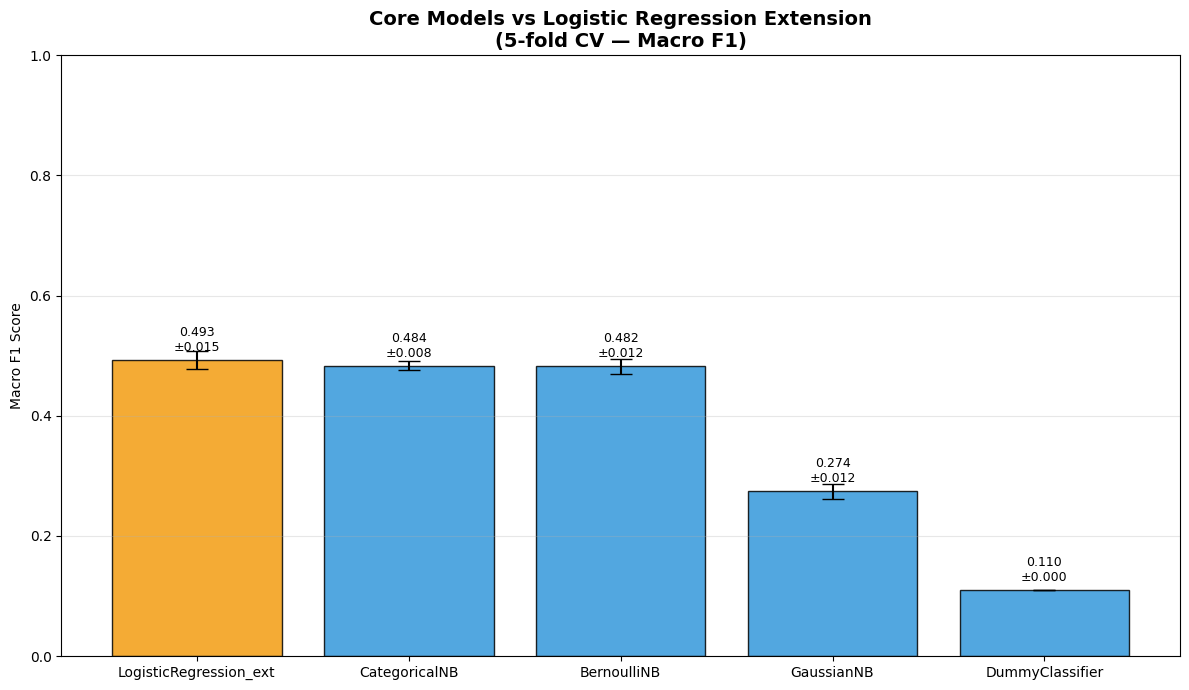

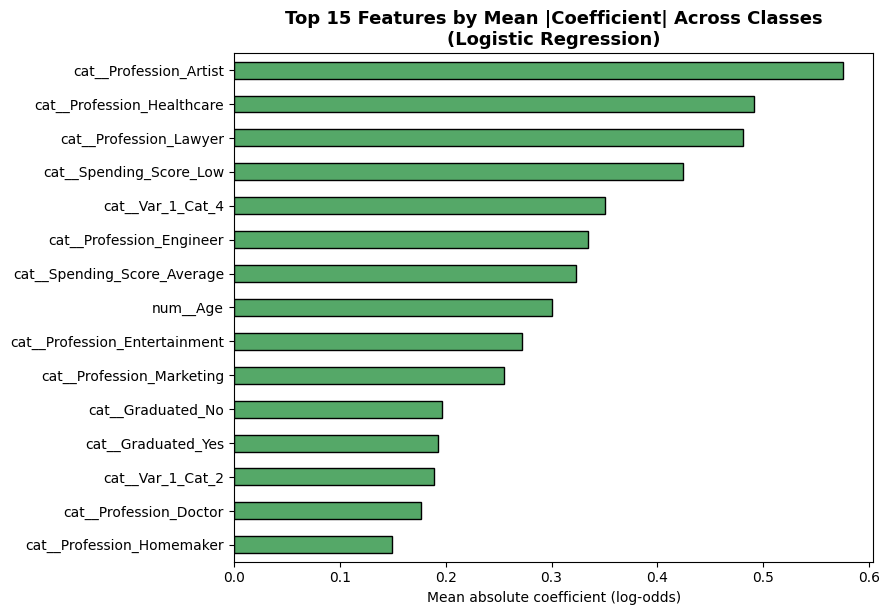


LR test macro F1: 0.5027 | LR CV macro F1: 0.4927 ± 0.0155


In [70]:
# Fit and evaluate the selected core model for comparison
selected_pipeline = core_pipelines[best_model_name]
selected_pipeline.fit(X_train, y_train)

selected_test_pred = selected_pipeline.predict(X_test)
selected_macro_f1 = f1_score(y_test, selected_test_pred, average='macro')

# Fit and evaluate Logistic Regression
lr_pipeline.fit(X_train, y_train)
lr_test_pred = lr_pipeline.predict(X_test)
lr_test_macro_f1 = f1_score(y_test, lr_test_pred, average='macro')
lr_test_accuracy = accuracy_score(y_test, lr_test_pred)

print("\nLocked-test comparison:")
print(f"  {best_model_name:20s} macro F1 = {selected_macro_f1:.4f}")
print(f"  LogisticRegression   macro F1 = {lr_test_macro_f1:.4f}")
print(f"  Difference (LR - selected)    = "
      f"{lr_test_macro_f1 - selected_macro_f1:+.4f}")
print("  Note: this is a benchmark only — the core-lab selection was locked using")
print(f"  training-only CV evidence before the test set was touched; {best_model_name}")
print("  remains the submitted model regardless of this comparison.")

# ---- Figure: CV comparison with LR added (extends Figure 9 / cv_comparison.png) ----
fig, ax = plt.subplots(figsize=(12, 7))
plot_df = pd.concat([cv_df, pd.DataFrame([{
    'Model': 'LogisticRegression_ext', 'Macro_F1_Mean': lr_cv['macro_f1_mean'],
    'Macro_F1_Std': lr_cv['macro_f1_std']
}])], ignore_index=True).sort_values('Macro_F1_Mean', ascending=False)

colors = ['#f39c12' if m == 'LogisticRegression_ext' else '#3498db' for m in plot_df['Model']]
bars = ax.bar(plot_df['Model'], plot_df['Macro_F1_Mean'], yerr=plot_df['Macro_F1_Std'],
              capsize=8, color=colors, edgecolor='black', alpha=0.85)
for bar, mean, std in zip(bars, plot_df['Macro_F1_Mean'], plot_df['Macro_F1_Std']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}\n±{std:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Core Models vs Logistic Regression Extension\n(5-fold CV — Macro F1)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Macro F1 Score'); ax.set_ylim(0, 1.0); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_comparison_with_lr.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Figure: LR coefficient magnitudes (the interpretability payoff CategoricalNB can't give) ----
lr_model = lr_pipeline.named_steps['model']
feature_names = lr_pipeline.named_steps['prep'].get_feature_names_out()
coef_df = pd.DataFrame(lr_model.coef_, index=lr_model.classes_, columns=feature_names)

top_n = 15
mean_abs_importance = coef_df.abs().mean(axis=0).sort_values(ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * top_n + 1)))
mean_abs_importance.sort_values().plot(kind='barh', ax=ax, color='#55A868', edgecolor='black')
ax.set_title(f'Top {top_n} Features by Mean |Coefficient| Across Classes\n(Logistic Regression)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean absolute coefficient (log-odds)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lr_coefficient_importance.png', dpi=300, bbox_inches='tight')
plt.show()

coef_df.to_csv(RESULTS_DIR / 'lr_coefficients_by_class.csv')
print(f"\nLR test macro F1: {lr_test_macro_f1:.4f} | LR CV macro F1: {lr_cv['macro_f1_mean']:.4f} ± {lr_cv['macro_f1_std']:.4f}")

# 5. LOCKED TEST EVALUATION
> This section evaluates the selected model on the locked test set.
> The test set has not been used for any model selection decisions.

### 5.1 Fit Selected Model on Full Training Data


In [71]:
print(f"\nFitting selected model ({best_model_name}) on full training data...")

# Get the selected model pipeline
selected_pipeline = core_pipelines[best_model_name]

# Fit on full training data
start_time = time.perf_counter()
selected_pipeline.fit(X_train, y_train)
fit_time = time.perf_counter() - start_time

print(f"  ✓ Model fitted in {fit_time:.2f} seconds")


Fitting selected model (CategoricalNB) on full training data...
  ✓ Model fitted in 0.13 seconds


### 5.2 Evaluate on Locked Test Set


In [72]:
print(f"\nEvaluating on locked test set...")

# Predict
start_time = time.perf_counter()
y_pred = selected_pipeline.predict(X_test)
inference_time = time.perf_counter() - start_time

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

# Per-class metrics
class_report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

print(f"\nTest Set Results:")
print(f"  - Accuracy: {accuracy:.4f}")
print(f"  - Macro F1: {macro_f1:.4f}")
print(f"  - Weighted F1: {weighted_f1:.4f}")
print(f"  - Inference Time: {inference_time:.4f} seconds")


Evaluating on locked test set...

Test Set Results:
  - Accuracy: 0.5143
  - Macro F1: 0.4867
  - Weighted F1: 0.4967
  - Inference Time: 0.0402 seconds


### 5.3 Per-Class Performance


In [73]:
# Create per-class metrics DataFrame
per_class_metrics = []
for class_label in sorted(y_test.unique()):
    metrics = class_report[str(class_label)]
    per_class_metrics.append({
        'Segment': class_label,
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1': metrics['f1-score'],
        'Support': metrics['support']
    })

per_class_df = pd.DataFrame(per_class_metrics)
print(per_class_df.to_string(index=False))

# Save per-class metrics
per_class_df.to_csv(RESULTS_DIR / 'per_class_metrics.csv', index=False)

Segment  Precision   Recall       F1  Support
      A   0.430412 0.423858 0.427110    394.0
      B   0.386139 0.209677 0.271777    372.0
      C   0.500000 0.664975 0.570806    394.0
      D   0.646000 0.711454 0.677149    454.0


### 5.4 Confusion Matrices


In [74]:
# Count confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=[f'True_{c}' for c in sorted(y_test.unique())],
                     columns=[f'Pred_{c}' for c in sorted(y_test.unique())])

print("\nCount Confusion Matrix:")
print(cm_df)

# Row-normalized confusion matrix
cm_row_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_row_norm_df = pd.DataFrame(cm_row_norm,
                              index=[f'True_{c}' for c in sorted(y_test.unique())],
                              columns=[f'Pred_{c}' for c in sorted(y_test.unique())])

print("\nRow-Normalized Confusion Matrix:")
print(cm_row_norm_df.round(3))

# Save confusion matrices
cm_df.to_csv(RESULTS_DIR / 'confusion_matrix_count.csv')
cm_row_norm_df.to_csv(RESULTS_DIR / 'confusion_matrix_row_norm.csv')



Count Confusion Matrix:
        Pred_A  Pred_B  Pred_C  Pred_D
True_A     167      57      87      83
True_B      94      78     160      40
True_C      46      32     262      54
True_D      81      35      15     323

Row-Normalized Confusion Matrix:
        Pred_A  Pred_B  Pred_C  Pred_D
True_A   0.424   0.145   0.221   0.211
True_B   0.253   0.210   0.430   0.108
True_C   0.117   0.081   0.665   0.137
True_D   0.178   0.077   0.033   0.711


### 5.5 Confusion Matrix Plots


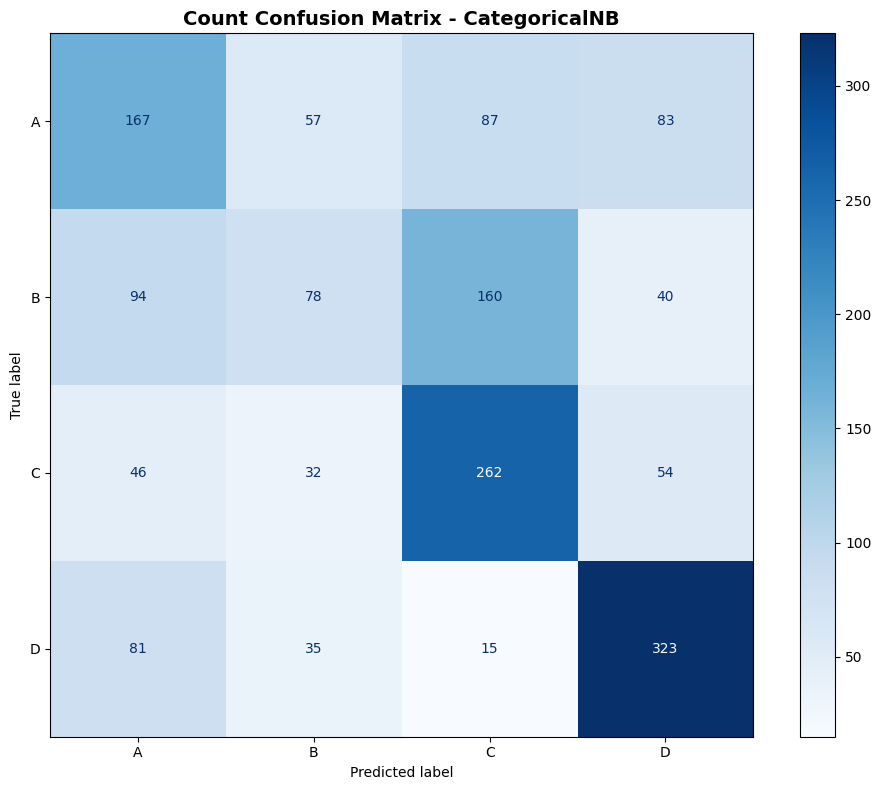

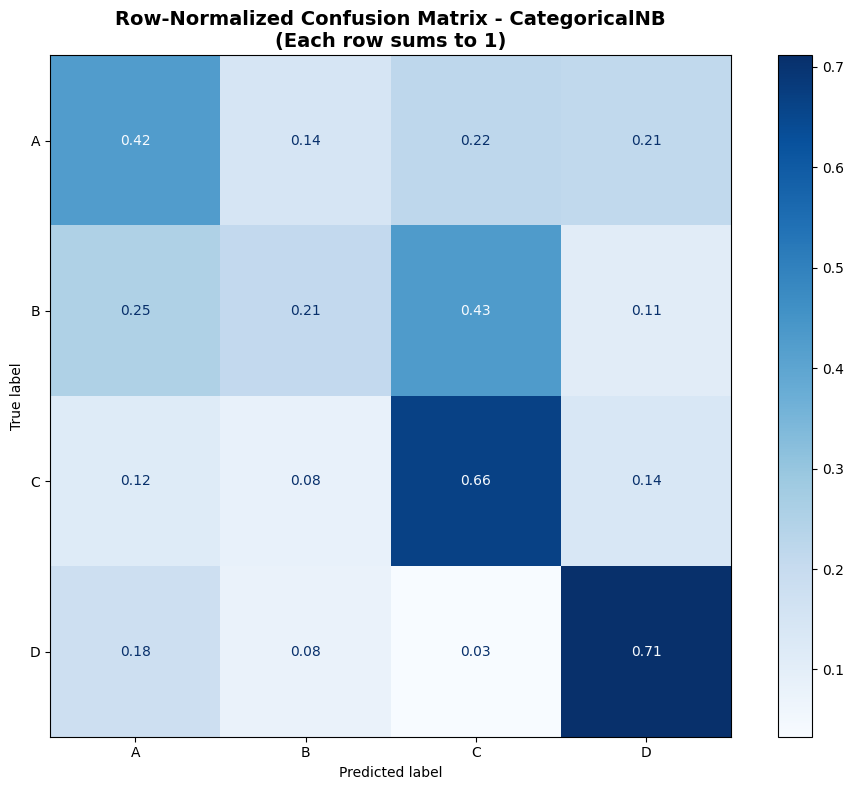


Confusion matrices saved to figures directory.


In [75]:
# Figure 11: Count Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=sorted(y_test.unique()))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Count Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_count.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 12: Row-Normalized Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_row_norm, 
                              display_labels=sorted(y_test.unique()))
disp.plot(ax=ax, cmap='Blues', values_format='.2f')
ax.set_title(f'Row-Normalized Confusion Matrix - {best_model_name}\n(Each row sums to 1)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_row_norm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nConfusion matrices saved to figures directory.")

### 5.6 Per-Class Precision/Recall/F1 Plot


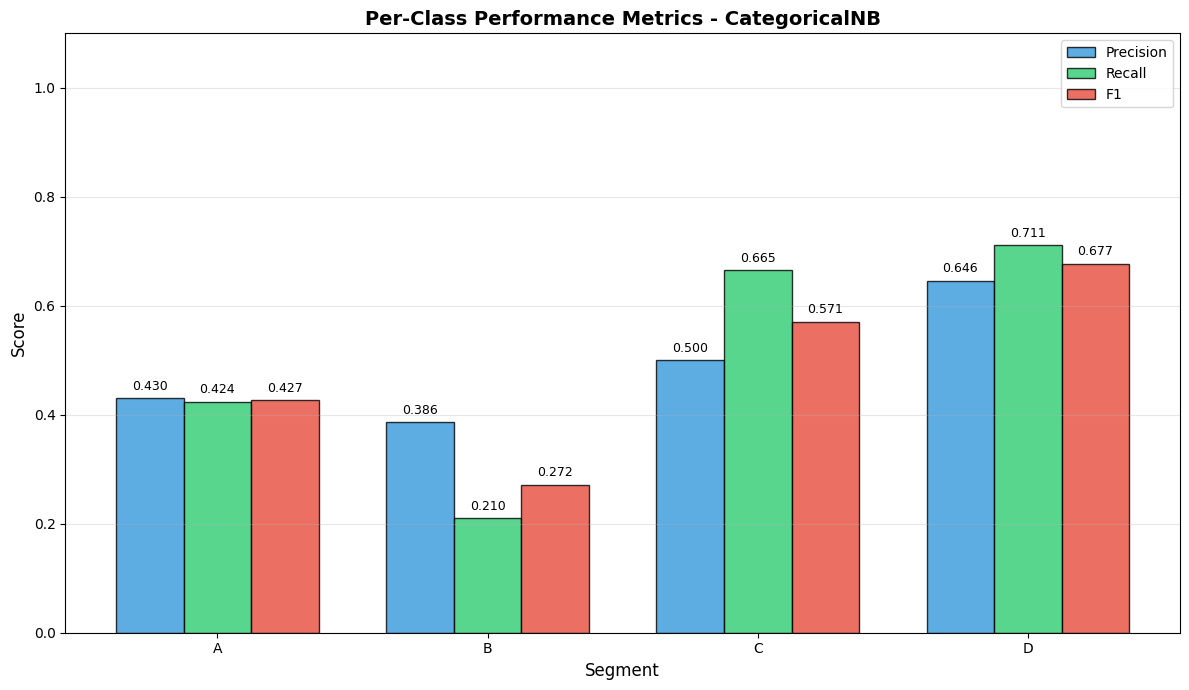


Figure saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures\per_class_metrics.png


In [76]:
# Figure 13: Per-class precision, recall, F1 grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(per_class_df))
width = 0.25

bars1 = ax.bar(x - width, per_class_df['Precision'], width, label='Precision', 
               color='#3498db', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x, per_class_df['Recall'], width, label='Recall',
               color='#2ecc71', edgecolor='black', alpha=0.8)
bars3 = ax.bar(x + width, per_class_df['F1'], width, label='F1',
               color='#e74c3c', edgecolor='black', alpha=0.8)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Per-Class Performance Metrics - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(per_class_df['Segment'])
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_class_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {FIGURES_DIR / 'per_class_metrics.png'}")

### 5.7 Save Test Results


In [77]:
# Create test results summary
test_results = {
    'model': best_model_name,
    'accuracy': accuracy,
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1,
    'inference_time_seconds': inference_time,
    'per_class_metrics': per_class_metrics
}

with open(ARTIFACTS_DIR / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2, default=str)

# Save predictions with probabilities
if hasattr(selected_pipeline, 'predict_proba'):
    try:
        probs = selected_pipeline.predict_proba(X_test)
        classes = selected_pipeline.classes_
        
        pred_df = pd.DataFrame({
            'ID': X_test.index.tolist(),
            'True_Segment': y_test.values,
            'Predicted_Segment': y_pred,
            'Max_Posterior': probs.max(axis=1)
        })
        
        # Add probability columns
        for i, cls in enumerate(classes):
            pred_df[f'Prob_{cls}'] = probs[:, i]
        
    except Exception as e:
        print(f"Could not get probabilities: {e}")
        pred_df = pd.DataFrame({
            'ID': X_test.index.tolist(),
            'True_Segment': y_test.values,
            'Predicted_Segment': y_pred
        })
else:
    pred_df = pd.DataFrame({
        'ID': X_test.index.tolist(),
        'True_Segment': y_test.values,
        'Predicted_Segment': y_pred
    })

pred_df.to_csv(RESULTS_DIR / 'test_predictions.csv', index=False)

print(f"\nTest predictions saved to: {RESULTS_DIR / 'test_predictions.csv'}")


Test predictions saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\results\test_predictions.csv


# 6. ERROR AND CONFIDENCE ANALYSIS

> This section analyzes misclassifications and confidence scores to understand
> model behavior and identify areas for improvement.

### 6.1 Identify Misclassified Cases


In [78]:
# Create error analysis DataFrame
error_df = pd.DataFrame({
    'ID': X_test.index.tolist(),
    'True_Segment': y_test.values,
    'Predicted_Segment': y_pred,
    'Correct': y_test.values == y_pred
})

# Add probabilities if available
if hasattr(selected_pipeline, 'predict_proba'):
    try:
        probs = selected_pipeline.predict_proba(X_test)
        error_df['Max_Posterior'] = probs.max(axis=1)
        error_df['Confidence_Level'] = pd.cut(
            error_df['Max_Posterior'],
            bins=[-np.inf, 0.50, 0.75, np.inf],
            labels=['Low_Review', 'Moderate_Review', 'High_Confidence']
        )
    except:
        error_df['Max_Posterior'] = np.nan
        error_df['Confidence_Level'] = 'Not_Available'

# Filter misclassified cases
misclassified = error_df[~error_df['Correct']].copy()
print(f"\nTotal misclassified cases: {len(misclassified)}")
print(f"Misclassification rate: {100 * len(misclassified) / len(error_df):.1f}%")


Total misclassified cases: 784
Misclassification rate: 48.6%


### 6.2 Analyze Top 5+ Misclassifications


In [79]:
# Get misclassification patterns
misclass_patterns = misclassified.groupby(['True_Segment', 'Predicted_Segment']).size().reset_index(name='Count')
misclass_patterns = misclass_patterns.sort_values('Count', ascending=False)

print("\nMisclassification Patterns (True -> Predicted):")
print(misclass_patterns.to_string(index=False))

# Analyze at least 5 specific errors
print("\n" + "="*60)
print("DETAILED ERROR ANALYSIS (5+ Cases)")
print("="*60)

# Select top 5 misclassifications to analyze
top_errors = misclass_patterns.head(5)

print("\nError Consequence Analysis:")
print("-" * 40)

error_analysis = []

for _, row in top_errors.iterrows():
    true_seg = row['True_Segment']
    pred_seg = row['Predicted_Segment']
    count = row['Count']
    
    # Analyze business impact of this error type
    if true_seg == 'A' and pred_seg == 'B':
        consequence = "High-value customer misclassified as lower-value segment"
        impact = "May result in inappropriate offers or lost revenue"
    elif true_seg == 'A' and pred_seg == 'C':
        consequence = "Premium customer misclassified as general segment"
        impact = "Missed opportunity for targeted premium offerings"
    elif true_seg == 'B' and pred_seg == 'A':
        consequence = "Budget-conscious customer misclassified as high-value"
        impact = "May receive inappropriate premium offers, wasting resources"
    elif true_seg == 'C' and pred_seg == 'A':
        consequence = "Regular customer misclassified as high-value"
        impact = "Over-investment in retention for lower-value segment"
    elif true_seg == 'D' and pred_seg == 'A':
        consequence = "At-risk customer misclassified as high-value"
        impact = "Missed retention opportunity"
    elif true_seg == 'D' and pred_seg == 'B':
        consequence = "At-risk customer misclassified as budget-conscious"
        impact = "Inappropriate retention strategy"
    else:
        consequence = f"Segment {true_seg} → {pred_seg} misclassification"
        impact = "May affect targeted communication and resource allocation"
    
    error_analysis.append({
        'True_Segment': true_seg,
        'Predicted_Segment': pred_seg,
        'Count': count,
        'Consequence': consequence,
        'Business_Impact': impact
    })
    
    print(f"\nError Type: {true_seg} → {pred_seg} ({count} cases)")
    print(f"  Consequence: {consequence}")
    print(f"  Impact: {impact}")

error_analysis_df = pd.DataFrame(error_analysis)
error_analysis_df.to_csv(RESULTS_DIR / 'error_analysis_detailed.csv', index=False)


Misclassification Patterns (True -> Predicted):
True_Segment Predicted_Segment  Count
           B                 C    160
           B                 A     94
           A                 C     87
           A                 D     83
           D                 A     81
           A                 B     57
           C                 D     54
           C                 A     46
           B                 D     40
           D                 B     35
           C                 B     32
           D                 C     15

DETAILED ERROR ANALYSIS (5+ Cases)

Error Consequence Analysis:
----------------------------------------

Error Type: B → C (160 cases)
  Consequence: Segment B → C misclassification
  Impact: May affect targeted communication and resource allocation

Error Type: B → A (94 cases)
  Consequence: Budget-conscious customer misclassified as high-value
  Impact: May receive inappropriate premium offers, wasting resources

Error Type: A → C (87 cases)
  Cons

### 6.3 Confidence Analysis



Confidence Score Distribution:
count    1614.000000
mean        0.629536
std         0.204038
min         0.295854
25%         0.456239
50%         0.578774
75%         0.780343
max         0.999810
Name: Max_Posterior, dtype: float64


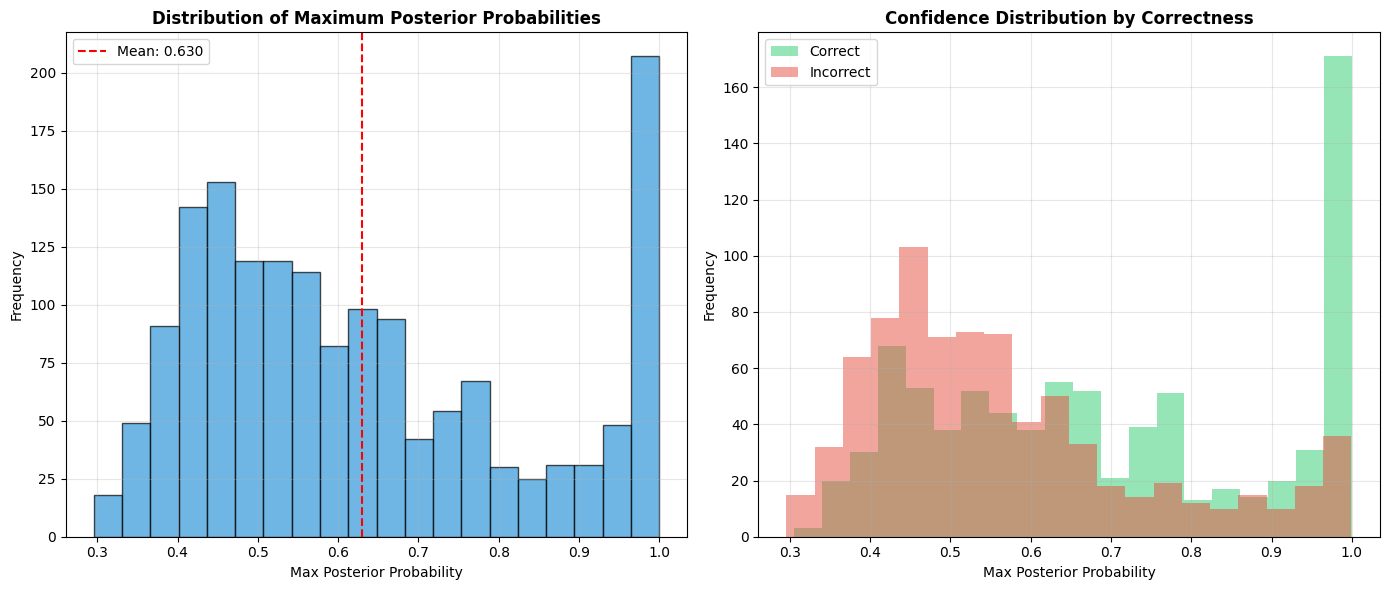


Figure saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures\confidence_distribution.png


In [80]:
if 'Max_Posterior' in error_df.columns:
    # Distribution of confidence scores
    print("\nConfidence Score Distribution:")
    print(error_df['Max_Posterior'].describe())
    
    # Figure 14: Confidence Distribution Histogram
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Overall confidence distribution
    axes[0].hist(error_df['Max_Posterior'].dropna(), bins=20, 
                 color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].axvline(error_df['Max_Posterior'].mean(), color='red', linestyle='--',
                    label=f'Mean: {error_df["Max_Posterior"].mean():.3f}')
    axes[0].set_title('Distribution of Maximum Posterior Probabilities', 
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Max Posterior Probability', fontsize=10)
    axes[0].set_ylabel('Frequency', fontsize=10)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Confidence by correctness
    correct_conf = error_df[error_df['Correct']]['Max_Posterior'].dropna()
    incorrect_conf = error_df[~error_df['Correct']]['Max_Posterior'].dropna()
    
    axes[1].hist(correct_conf, bins=20, alpha=0.5, label='Correct', color='#2ecc71')
    axes[1].hist(incorrect_conf, bins=20, alpha=0.5, label='Incorrect', color='#e74c3c')
    axes[1].set_title('Confidence Distribution by Correctness', 
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Max Posterior Probability', fontsize=10)
    axes[1].set_ylabel('Frequency', fontsize=10)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'confidence_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nFigure saved to: {FIGURES_DIR / 'confidence_distribution.png'}")

### 6.4 Coverage-Selective Error Analysis



Coverage-Selective Error Table:
 Threshold  Coverage  Selective_Error  Review_Rate
      0.30     0.999            0.485        0.001
      0.35     0.976            0.479        0.024
      0.40     0.903            0.463        0.097
      0.45     0.770            0.435        0.230
      0.50     0.659            0.408        0.341
      0.55     0.547            0.374        0.453
      0.60     0.452            0.344        0.548
      0.65     0.365            0.319        0.635
      0.70     0.302            0.292        0.698
      0.75     0.258            0.289        0.742
      0.80     0.204            0.290        0.796
      0.85     0.185            0.281        0.815
      0.90     0.163            0.273        0.837


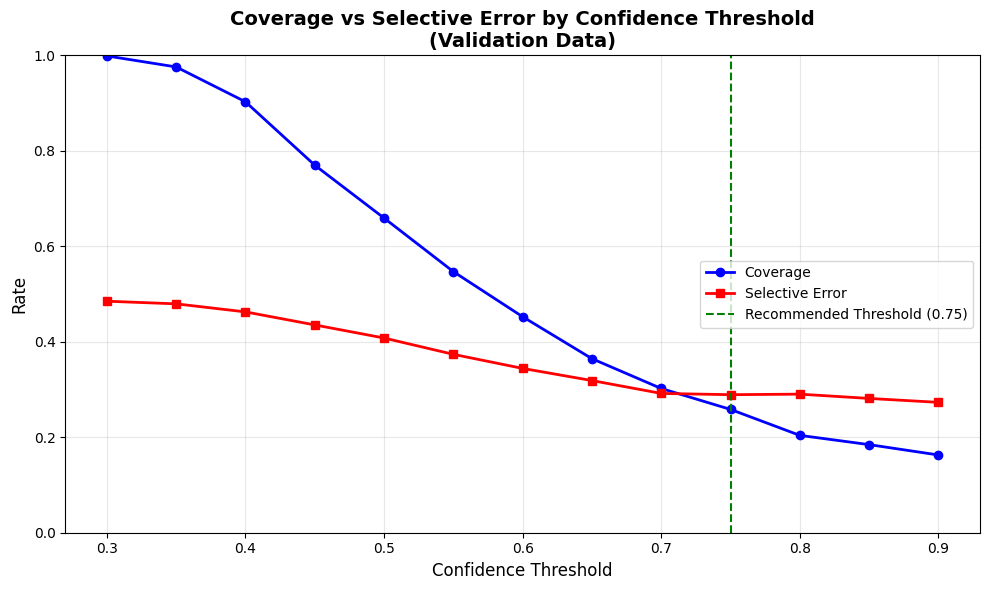


Figure saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures\coverage_selective_error.png

Frozen Review Threshold: 0.75
(Selected based on validation coverage-error trade-off, before test evaluation)

Policy:
  - Max Posterior ≥ 0.75: High confidence, return prediction
  - 0.5 ≤ Max Posterior < 0.75: Moderate confidence, review flag
  - Max Posterior < 0.5: Low confidence, manual analysis


In [81]:
   """
    COVERAGE-SELECTIVE ERROR ANALYSIS
    
    This analysis helps choose a confidence threshold for review/abstention.
    - Coverage: Fraction of cases automatically classified (above threshold)
    - Selective Error: Error rate among automatically classified cases
    
    A higher threshold means fewer cases automatically classified (lower coverage)
    but potentially lower error rate among those classified.
    """
    
    # Use validation data only (training data) to select threshold
    # Get predictions on training data for threshold selection
if hasattr(selected_pipeline, 'predict_proba'):
    try:
        train_probs = selected_pipeline.predict_proba(X_train)
        train_max_probs = train_probs.max(axis=1)
        train_preds = selected_pipeline.predict(X_train)
        train_true = y_train.values
        
        # Calculate coverage and selective error at different thresholds
        thresholds = np.arange(0.30, 0.95, 0.05)
        coverage_errors = []
        
        for threshold in thresholds:
            # Cases above threshold (automatically classified)
            above_threshold = train_max_probs >= threshold
            coverage = np.mean(above_threshold)
            
            if np.sum(above_threshold) > 0:
                # Error rate among automatically classified cases
                auto_preds = train_preds[above_threshold]
                auto_true = train_true[above_threshold]
                selective_error = 1 - accuracy_score(auto_true, auto_preds)
            else:
                selective_error = 1.0
            
            coverage_errors.append({
                'Threshold': threshold,
                'Coverage': coverage,
                'Selective_Error': selective_error,
                'Review_Rate': 1 - coverage
            })
        
        coverage_df = pd.DataFrame(coverage_errors)
        coverage_df.to_csv(RESULTS_DIR / 'coverage_selective_error.csv', index=False)
        
        print("\nCoverage-Selective Error Table:")
        print(coverage_df.round(3).to_string(index=False))
        
        # Figure 15: Coverage-Selective Error Curve
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.plot(coverage_df['Threshold'], coverage_df['Coverage'], 
                'b-o', label='Coverage', linewidth=2)
        ax.plot(coverage_df['Threshold'], coverage_df['Selective_Error'], 
                'r-s', label='Selective Error', linewidth=2)
        
        # Find optimal threshold (balance coverage and error)
        ax.axvline(x=0.75, color='green', linestyle='--', 
                   label='Recommended Threshold (0.75)')
        
        ax.set_xlabel('Confidence Threshold', fontsize=12)
        ax.set_ylabel('Rate', fontsize=12)
        ax.set_title('Coverage vs Selective Error by Confidence Threshold\n(Validation Data)',
                     fontsize=14, fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.grid(alpha=0.3)
        ax.legend(loc='center right')
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'coverage_selective_error.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nFigure saved to: {FIGURES_DIR / 'coverage_selective_error.png'}")
        
        # Choose and freeze threshold
        FROZEN_THRESHOLD = 0.75  # Based on validation trade-off
        print(f"\nFrozen Review Threshold: {FROZEN_THRESHOLD}")
        print("(Selected based on validation coverage-error trade-off, before test evaluation)")
        print("\nPolicy:")
        print(f"  - Max Posterior ≥ {FROZEN_THRESHOLD}: High confidence, return prediction")
        print(f"  - {FROZEN_THRESHOLD - 0.25} ≤ Max Posterior < {FROZEN_THRESHOLD}: Moderate confidence, review flag")
        print(f"  - Max Posterior < {FROZEN_THRESHOLD - 0.25}: Low confidence, manual analysis")
        
    except Exception as e:
        print(f"Could not perform coverage analysis: {e}")
else:
    print("Model does not support predict_proba; confidence analysis skipped.")

### 6.5 Model Calibration Assessment


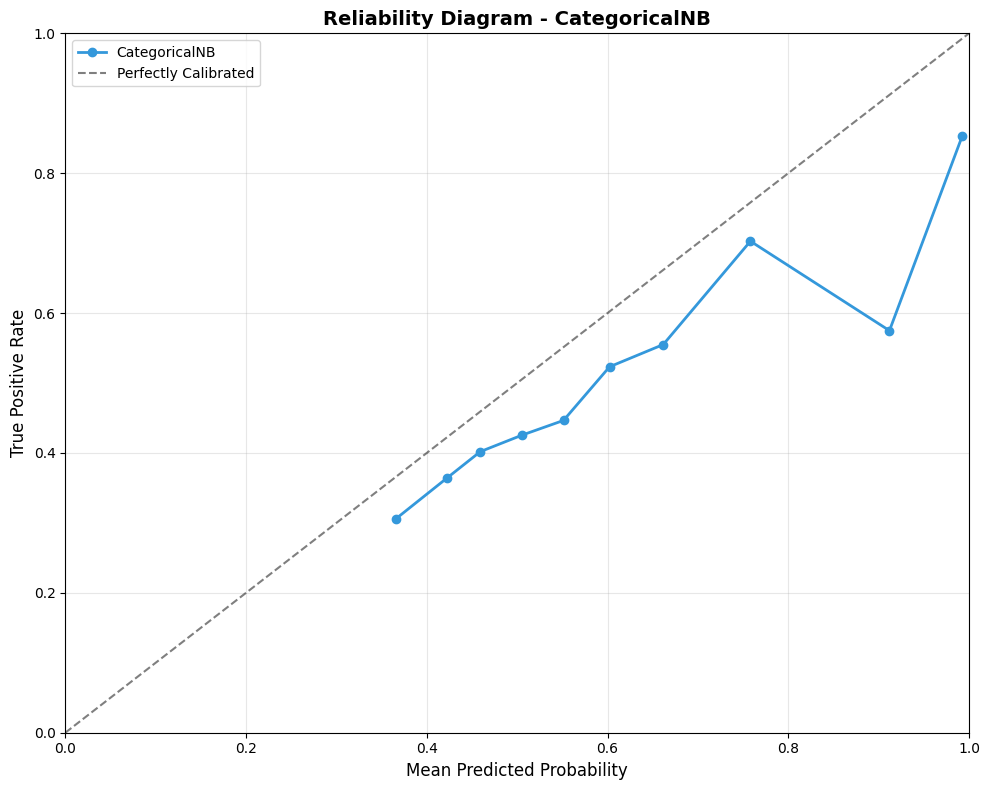


Figure saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures\calibration_diagram.png

Calibration Interpretation:
  - Points above the diagonal indicate under-confident predictions
  - Points below the diagonal indicate over-confident predictions
  - Naive Bayes probabilities may be poorly calibrated when assumptions are violated


In [82]:
if hasattr(selected_pipeline, 'predict_proba'):
    try:
        from sklearn.calibration import calibration_curve
        
        # Get probabilities on training data for calibration
        train_probs = selected_pipeline.predict_proba(X_train)
        train_max_probs = train_probs.max(axis=1)
        train_true_probs = np.array([1 if y_train.iloc[i] == selected_pipeline.classes_[np.argmax(train_probs[i])] 
                                    else 0 for i in range(len(y_train))])
        
        # Figure 16: Reliability Diagram
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Calibration curve
        fraction_positive, mean_predicted_value = calibration_curve(
            train_true_probs, train_max_probs, n_bins=10, strategy='quantile'
        )
        
        ax.plot(mean_predicted_value, fraction_positive, 'o-', 
                label=best_model_name, color='#3498db', linewidth=2)
        ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', alpha=0.5)
        
        ax.set_xlabel('Mean Predicted Probability', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title(f'Reliability Diagram - {best_model_name}', fontsize=14, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend()
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'calibration_diagram.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nFigure saved to: {FIGURES_DIR / 'calibration_diagram.png'}")
        print("\nCalibration Interpretation:")
        print("  - Points above the diagonal indicate under-confident predictions")
        print("  - Points below the diagonal indicate over-confident predictions")
        print("  - Naive Bayes probabilities may be poorly calibrated when assumptions are violated")
        
    except Exception as e:
        print(f"Calibration analysis not available: {e}")
else:
    print("Model does not support predict_proba; calibration analysis skipped.")

# 7. NEW CUSTOMER PREDICTION FUNCTION

### 7.1 Define Expected Schema and Validations

In [83]:
# Define expected feature schema
FEATURE_SCHEMA = {
    'Gender': {'type': 'category', 'allowed_values': ['Male', 'Female']},
    'Ever_Married': {'type': 'category', 'allowed_values': ['Yes', 'No']},
    'Age': {'type': 'numeric', 'min': 18, 'max': 90, 'required': True},
    'Graduated': {'type': 'category', 'allowed_values': ['Yes', 'No']},
    'Profession': {'type': 'category', 'allowed_values': ['Healthcare', 'Engineer', 'Lawyer', 'Artist', 
                                                         'Executive', 'Doctor', 'Marketing', 'Homemaker', 
                                                         'Entertainment']},
    'Work_Experience': {'type': 'numeric', 'min': 0, 'max': 50},
    'Spending_Score': {'type': 'category', 'allowed_values': ['Low', 'Average', 'High']},
    'Family_Size': {'type': 'numeric', 'min': 1, 'max': 10},
    'Var_1': {'type': 'category', 'allowed_values': ['Cat_1', 'Cat_2', 'Cat_3', 'Cat_4', 'Cat_5', 'Cat_6', 'Cat_7']}
}

### 7.2 Prediction Function


In [84]:
def predict_customer_segment(customer_profile, model=selected_pipeline, threshold=FROZEN_THRESHOLD if 'FROZEN_THRESHOLD' in dir() else 0.75):
    """
    Predict customer segment for a new customer profile.
    
    Parameters:
    -----------
    customer_profile : dict
        Dictionary containing customer features
    model : Pipeline
        Fitted model pipeline
    threshold : float
        Confidence threshold for review recommendation
    
    Returns:
    --------
    dict : Prediction results with segment, probabilities, and review recommendation
    """
    
    # 1. Validate input schema
    missing_fields = []
    invalid_values = []
    
    for field, schema in FEATURE_SCHEMA.items():
        # Check required fields
        if schema.get('required', False) and field not in customer_profile:
            missing_fields.append(field)
            continue
        
        if field not in customer_profile:
            continue
        
        value = customer_profile[field]
        
        # Check type
        if schema['type'] == 'numeric':
            try:
                value = float(value)
                customer_profile[field] = value
            except (ValueError, TypeError):
                invalid_values.append(f"{field}: {value} (expected numeric)")
                continue
            
            # Check range
            if 'min' in schema and value < schema['min']:
                invalid_values.append(f"{field}: {value} (min: {schema['min']})")
            if 'max' in schema and value > schema['max']:
                invalid_values.append(f"{field}: {value} (max: {schema['max']})")
                
        elif schema['type'] == 'category':
            if 'allowed_values' in schema and value not in schema['allowed_values']:
                invalid_values.append(f"{field}: {value} (allowed: {schema['allowed_values']})")
    
    if missing_fields:
        raise ValueError(f"Missing mandatory fields: {missing_fields}")
    
    if invalid_values:
        raise ValueError(f"Invalid values: {invalid_values}")
    
    # 2. Create DataFrame from profile
    try:
        # Ensure all required columns are present
        profile_df = pd.DataFrame([customer_profile])
        
        # Handle missing optional fields (impute with mode)
        for col in MODEL_FEATURES:
            if col not in profile_df.columns:
                # Use training data mode for categorical, median for numeric
                if col in CATEGORICAL_COLS:
                    mode_val = X_train[col].mode().iloc[0] if not X_train[col].mode().empty else None
                    profile_df[col] = mode_val
                elif col in NUMERIC_COLS:
                    median_val = X_train[col].median()
                    profile_df[col] = median_val
                else:
                    profile_df[col] = None
        
        # Ensure Work_Experience_Cleaned is used if Work_Experience is provided
        if 'Work_Experience' in profile_df.columns:
            profile_df['Work_Experience_Cleaned'] = profile_df['Work_Experience']
            # Apply suspicious zero handling
            age = profile_df['Age'].iloc[0]
            work_exp = profile_df['Work_Experience'].iloc[0]
            if work_exp == 0 and age > 22:
                profile_df['Work_Experience_Cleaned'] = np.nan
        
        # Select only the columns the model expects
        profile_df = profile_df[MODEL_FEATURES]
        
    except Exception as e:
        raise ValueError(f"Error creating input DataFrame: {e}")
    
    # 3. Make prediction
    try:
        pred = model.predict(profile_df)[0]
    except Exception as e:
        raise RuntimeError(f"Prediction failed: {e}")
    
    # 4. Get probabilities if available
    result = {
        'predicted_segment': str(pred),
        'review_recommendation': 'manual_review_no_probability'
    }
    
    if hasattr(model, 'predict_proba'):
        try:
            probs = model.predict_proba(profile_df)[0]
            distribution = {str(c): float(p) for c, p in zip(model.classes_, probs)}
            max_prob = float(probs.max())
            
            result.update({
                'posterior_distribution': distribution,
                'max_posterior': max_prob
            })
            
            # Determine review recommendation
            if max_prob >= threshold:
                result['review_recommendation'] = 'normal_review'
            elif max_prob >= threshold - 0.25:
                result['review_recommendation'] = 'explicit_review'
            else:
                result['review_recommendation'] = 'manual_analysis'
                
        except Exception as e:
            result['review_recommendation'] = 'error_getting_probabilities'
            result['probability_error'] = str(e)
    
    return result

### 7.3 Test Prediction Function


In [85]:
# Create a sample customer profile for testing
sample_profile = {
    'Gender': 'Male',
    'Ever_Married': 'Yes',
    'Age': 35,
    'Graduated': 'Yes',
    'Profession': 'Engineer',
    'Work_Experience': 5,
    'Spending_Score': 'Average',
    'Family_Size': 3,
    'Var_1': 'Cat_6'
}

print("\nTesting prediction function with sample profile:")
print(sample_profile)

try:
    prediction_result = predict_customer_segment(sample_profile)
    print("\nPrediction Result:")
    for key, value in prediction_result.items():
        if key == 'posterior_distribution':
            print(f"  {key}:")
            for seg, prob in value.items():
                print(f"    {seg}: {prob:.4f}")
        else:
            print(f"  {key}: {value}")
except Exception as e:
    print(f"Error: {e}")


Testing prediction function with sample profile:
{'Gender': 'Male', 'Ever_Married': 'Yes', 'Age': 35, 'Graduated': 'Yes', 'Profession': 'Engineer', 'Work_Experience': 5, 'Spending_Score': 'Average', 'Family_Size': 3, 'Var_1': 'Cat_6'}

Prediction Result:
  predicted_segment: A
  review_recommendation: manual_analysis
  posterior_distribution:
    A: 0.3354
    B: 0.3352
    C: 0.2935
    D: 0.0359
  max_posterior: 0.33538989165618466


# 8. SAVE AND VERIFY ARTIFACTS

> This section saves all model artifacts and verifies reproducibility.

### 8.1 Save Fitted Model


In [86]:
# Save the selected pipeline
model_path = MODELS_DIR / 'selected_pipeline.joblib'
joblib.dump(selected_pipeline, model_path)
print(f"✓ Model saved to: {model_path}")

# Save preprocessor separately (if needed)
preprocessor_path = MODELS_DIR / 'preprocessor.joblib'
if hasattr(selected_pipeline, 'named_steps') and 'prep' in selected_pipeline.named_steps:
    joblib.dump(selected_pipeline.named_steps['prep'], preprocessor_path)
    print(f"✓ Preprocessor saved to: {preprocessor_path}")

✓ Model saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\models\selected_pipeline.joblib
✓ Preprocessor saved to: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\models\preprocessor.joblib


### 8.2 Save Additional Results


In [87]:

# Save error analysis
error_df.to_csv(RESULTS_DIR / 'error_analysis.csv', index=False)

# Save feature importance insights (if available)
if hasattr(selected_pipeline, 'named_steps') and 'model' in selected_pipeline.named_steps:
    model = selected_pipeline.named_steps['model']
    if hasattr(model, 'feature_log_prob_'):
        # For Naive Bayes, we can get feature importance by class
        # This is more complex and model-specific
        pass

### 8.3 Reproducibility Test: Reload and Verify


In [88]:
# Reload the model
loaded_model = joblib.load(model_path)
print(f"✓ Model reloaded from: {model_path}")

# Verify predictions match on a small sample
sample_size = min(10, len(X_test))
test_sample = X_test.iloc[:sample_size]

original_pred = selected_pipeline.predict(test_sample)
reloaded_pred = loaded_model.predict(test_sample)

if np.array_equal(original_pred, reloaded_pred):
    print(f"✓ Predictions match on {sample_size} test samples")
    print("  Reproducibility confirmed!")
else:
    print("⚠️ WARNING: Predictions do not match. Check model persistence.")

✓ Model reloaded from: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\models\selected_pipeline.joblib
✓ Predictions match on 10 test samples
  Reproducibility confirmed!
